Assignment : RCNN &Yolo

In [ ]:
1. What is the main purpose of RCNN in object detection?

The main purpose of R-CNN (Regions with Convolutional Neural Networks) in object detection is to accurately detect and localize objects within an image by combining region proposals with deep convolutional neural network features.

How it works (simplified):

Region Proposals: First, R-CNN uses an external algorithm (like Selective Search) to generate a set of region proposals (potential object-containing bounding boxes).

Feature Extraction: Each region is warped to a fixed size and passed through a CNN (like AlexNet) to extract deep features.

Classification & Regression:

A classifier (like SVM) assigns a class label (e.g., cat, car, background) to each region.

A regressor fine-tunes the coordinates of the bounding box for better localization.

✅ Key advantage: By combining traditional region proposals with powerful CNN features, R-CNN significantly improved accuracy compared to older methods that relied only on handcrafted features (like HOG or SIFT).



In [ ]:
2. What is the difference between Fast RCNN and Faster RCNN?

 Fast R-CNN vs Faster R-CNN
Aspect	Fast R-CNN	Faster R-CNN
Region Proposals	Uses an external region proposal method like Selective Search, which is slow and not trainable.	Introduces a Region Proposal Network (RPN) that generates region proposals inside the network, making it much faster and end-to-end trainable.
Architecture	- Entire image is passed through a CNN to get a feature map.
- ROI Pooling extracts features for each region proposal.
- Regions are classified and bounding boxes are regressed.	Same pipeline as Fast R-CNN but adds the RPN before ROI Pooling to generate proposals using the feature map itself.
Speed	Faster than original R-CNN but bottlenecked by external proposal generation (~2 seconds/image).	Significantly faster because region proposals come from the RPN (~5–10× faster than Fast R-CNN).
Training	Partially end-to-end; region proposal step is separate.	Fully end-to-end: RPN and detector are trained jointly (shared convolutional layers).
Key Contribution	Introduced ROI Pooling for speed and efficiency.	Introduced RPN for fast, learnable proposals.

📌 Key Difference in One Line
Fast R-CNN depends on slow, external region proposal methods.
Faster R-CNN uses a built-in, trainable Region Proposal Network, making it much faster and fully integrated.


In [ ]:
3. How does YOLO handle object detection in real-time?

YOLO treats object detection as a single regression problem — it directly predicts bounding boxes and class probabilities for multiple objects in an image in one forward pass through the network.

⚡️ Why YOLO is real-time
1️⃣ Single unified network
The entire image is passed through a single convolutional neural network once.

Unlike R-CNN variants (which run the CNN for each region proposal), YOLO processes the whole image at once, avoiding redundant computation.

2️⃣ Grid-based prediction
YOLO divides the input image into an S × S grid (e.g., 7×7 in YOLOv1).

Each grid cell predicts:

Multiple bounding boxes.

Confidence scores.

Class probabilities.

So, instead of proposing regions, it learns to directly localize and classify objects simultaneously.

3️⃣ Fully connected output
After feature extraction, YOLO uses fully connected layers to output all bounding boxes and class probabilities together.

This design keeps it fast and simple compared to methods that rely on multi-stage pipelines.

4️⃣ Optimized for speed
YOLO’s architecture is lightweight compared to heavier models (like R-CNNs).

Subsequent YOLO versions (v2, v3, v4, v5, v7, v8) further optimize speed with:

Better backbone networks.

Faster upsampling.

Efficient anchor box handling.

Improved post-processing (Non-Maximum Suppression).

🚀 Result
Because YOLO predicts everything in one pass, it’s extremely fast (often reaching real-time speeds of 30–60 FPS on modern GPUs).

This makes it suitable for applications like autonomous driving, video surveillance, and robotics.

In [ ]:
4. Explain the concept of Region Proposal Networks (RPN) in Faster RCNN?

A Region Proposal Network (RPN) is a small, fully convolutional neural network that predicts region proposals — i.e., potential object bounding boxes — directly from the image feature map.

👉 Key idea: Instead of using slow external methods like Selective Search, RPNs learn to generate region proposals automatically and efficiently as part of the model.

🧩 Where does it fit in Faster R-CNN?
The input image goes through a CNN backbone (like VGG, ResNet) → produces a feature map.

The RPN slides a small window over this feature map.

For each window, it predicts:

Objectness score: Is there an object or just background?

Bounding box coordinates: Refines anchor boxes to fit the object better.

Top-N proposals (after Non-Maximum Suppression) are passed to the second part of Faster R-CNN (the Fast R-CNN detection head) for classification and final box refinement.

⚙️ How does the RPN work?
✅ Key steps:

1️⃣ Sliding window:

A small network slides over the entire feature map.

For each position, it looks at a fixed-size n × n region (e.g., 3×3).

2️⃣ Anchors:

For each position, multiple anchor boxes (with different scales & aspect ratios) are generated.

Example: 3 scales × 3 aspect ratios = 9 anchors per location.

3️⃣ Outputs for each anchor:

Objectness score (2 classes): Object vs. background.

BBox regression: Offsets to adjust the anchor to fit the actual object.

4️⃣ Post-processing:

Apply Non-Maximum Suppression (NMS) to remove redundant proposals.

Keep top-N proposals (e.g., top 300).

🟢 Key advantage
✅ The RPN shares the same feature map with the detection head, making the whole pipeline:

Fully end-to-end trainable

Much faster than external region proposal methods

More accurate because it learns what good proposals look like!

🔑 In one line
A Region Proposal Network (RPN) is a learnable module in Faster R-CNN that generates candidate object regions efficiently, replacing slow traditional methods like Selective Search.

In [ ]:
5. How does YOLOv9 improve upon its predecessors?

YOLOv9 is an evolution of the YOLO (You Only Look Once) family — it keeps the real-time speed of YOLO but pushes for better accuracy, efficiency, and scalability.
It was introduced by the YOLO team (from the original YOLO lineage) and brings some unique innovations compared to previous versions.

🔑 Key improvements in YOLOv9
✅ 1️⃣ **Introduces Generalized Efficient Layer Aggregation Network (GELAN)
GELAN is a new backbone and neck design that combines ideas from ELAN (used in YOLOv7) and other efficient connection patterns.

It better balances depth, width, and layer aggregation, improving feature reuse and gradient flow — leading to higher accuracy without a huge cost in speed.

✅ 2️⃣ Semantic and Efficient Re-parameterization (RepOptimizer)
YOLOv9 introduces a novel training technique called Programmable Gradient Information Distillation (PGID).

This makes the optimization process more robust, enabling the model to converge better while keeping the inference structure efficient.

The re-parameterization trick helps the model be more efficient at inference time by merging layers.

✅ 3️⃣ Better scaling rules
YOLOv9 improves the scaling strategy to handle tiny models for edge devices and large models for server-side detection.

This makes it more flexible for tasks like drones, mobile devices, or high-res video streams.

✅ 4️⃣ Accuracy & Speed
In benchmarks, YOLOv9 achieves better mAP (mean Average Precision) than YOLOv8 and YOLOv7 on common datasets (like COCO), while maintaining comparable or even faster FPS.

It closes the gap with other top detectors while keeping YOLO’s famous speed.

✅ 5️⃣ Open & Extensible
YOLOv9 provides cleaner, more modular code and a pipeline that’s easy to integrate with other tasks like instance segmentation and pose estimation.

🏆 What does this mean practically?
Better accuracy: Improved detection for small and overlapping objects.

Faster inference: Still real-time on modern GPUs and edge devices.

More robust training: New optimization methods make it easier to get good results with less tuning.

📌 In one line:
YOLOv9 improves upon its predecessors by combining an efficient new backbone (GELAN), smarter optimization (PGID & RepOptimizer), and improved scaling — achieving higher accuracy while keeping YOLO’s hallmark real-time speed.

In [ ]:
6. What role does non-max suppression play in YOLO object detection?

What is Non-Maximum Suppression (NMS)?
Non-Maximum Suppression (NMS) is a post-processing step that removes duplicate or overlapping bounding boxes for the same object, keeping only the best one.

🟢 Why is NMS needed in YOLO?
In YOLO:

For each grid cell and anchor box, the model predicts multiple bounding boxes with confidence scores and class probabilities.

Many of these boxes overlap, especially if they cover the same object.

Without NMS, you’d get multiple detections for the same object — messy results!

✅ NMS filters these by:

Keeping the box with the highest confidence score.

Removing other boxes that overlap too much (using an IoU threshold, e.g., 0.5).

Repeating this for each class.

⚙️ How does it work?
Step-by-step for a single class:
1️⃣ Sort all detected boxes by their confidence scores (high to low).
2️⃣ Pick the box with the highest score → keep it.
3️⃣ Compute IoU between this box and all remaining boxes.
4️⃣ Remove boxes with IoU > threshold (e.g., 0.5).
5️⃣ Repeat until no boxes remain.

✅ In YOLO, NMS does two things:
Removes redundant boxes → cleaner results.

Keeps detection fast and simple → all predictions in one shot + simple filtering.

📌 In one line:
Non-Maximum Suppression (NMS) in YOLO removes duplicate and overlapping bounding boxes for the same object, ensuring that each object is detected with only one tight, best-fit box.

In [ ]:
7. Describe the data preparation process for training YOLOv9?

🟢 1️⃣ Collect & Organize Images
✅ Gather your dataset of images that contain the objects you want to detect.

Images should have good diversity (lighting, angles, backgrounds, object sizes).

Common datasets: COCO, Pascal VOC, or your custom data.

📂 Typical folder structure:


dataset/
 ├── images/
 │   ├── train/
 │   ├── val/
 │   └── test/
 ├── labels/
 │   ├── train/
 │   ├── val/
 │   └── test/
Each image must have a corresponding label file with the same name but .txt extension.

🟢 2️⃣ Label the objects
✅ For each image, annotate:

Bounding boxes: (x_center, y_center, width, height)

Class ID

The YOLO format is normalized: all values are relative to image size and range between 0 and 1.

📌 Example YOLO label file:

php-template
Copy code
<class_id> <x_center> <y_center> <width> <height>
Example:

Copy code
0 0.45 0.32 0.20 0.15
2 0.60 0.55 0.10 0.08
This means two objects: one of class 0, another of class 2.

x_center and y_center are relative to image width and height.

✅ You can use tools like:

LabelImg

Roboflow

CVAT

Makesense.ai

🟢 3️⃣ Split the dataset
Divide your data into:

Training set (~70–80%)

Validation set (~10–20%)

Test set (~10–20%)

This helps evaluate performance and prevent overfitting.

🟢 4️⃣ Prepare config files
For YOLOv9, you’ll typically need:

data.yaml (or dataset.yaml): specifies paths to train/val images, class names, number of classes.

Example data.yaml:


train: dataset/images/train
val: dataset/images/val

nc: 3   # number of classes
names: ['cat', 'dog', 'bird']  # class names
🟢 5️⃣ Verify annotations
✅ Always check that:

Every image has a matching .txt label file.

Class IDs are in the valid range [0, nc-1].

Normalized coordinates are correct.

Use visualization tools to preview bounding boxes.

🟢 6️⃣ Optional: Data augmentation
YOLOv9 and modern training pipelines like Ultralytics YOLO auto-apply augmentations:

Random flip

Scaling

Mosaic

HSV adjustment

Random cropping

This helps models generalize better!

✅ In one line
YOLOv9 data preparation means annotating images in YOLO format (normalized bounding boxes & class IDs), organizing them into train/val/test splits, and providing a simple config file — then you’re ready to train!

In [ ]:
8. What is the significance of anchor boxes in object detection models like YOLOv9?

 What are anchor boxes?
Anchor boxes (also called prior boxes) are predefined bounding boxes of different shapes and sizes that help the model predict objects with varying aspect ratios and scales in a single image.

🟢 Why do we need them?
👉 Real-world images have:

Small objects 🐦

Large objects 🚌

Tall/narrow objects 🧍

Short/wide objects 🛋️

Without anchor boxes, a detector would struggle to fit these variations with just one default box per grid cell.

⚙️ How do anchor boxes work in YOLO?
1️⃣ The image is divided into a grid (e.g., 13×13 or 80×80, depending on the feature map size).
2️⃣ At each grid cell, multiple anchor boxes (e.g., 3 per cell) are placed with different aspect ratios and sizes.
3️⃣ The model learns adjustments:

Shifts (x, y) → to position the box correctly.

Scale (w, h) → to resize the box to match the object tightly.

Objectness score → how likely it contains an object.

Class probabilities → what object it is.

🧩 Example
Suppose you have 3 anchors:

Anchor 1: square (1:1)

Anchor 2: wide rectangle (2:1)

Anchor 3: tall rectangle (1:2)

For an object that’s tall, the model will mostly adjust the tall anchor to fit it perfectly.

✅ Benefits
Better matching: Handles objects of varying shapes & sizes in the same image.

Multiple detections: Each grid cell can detect multiple objects (thanks to multiple anchors).

Improves accuracy: Makes it easier for the network to learn bounding box regression.

🟢 YOLOv9 & anchor boxes
YOLOv9 (like YOLOv5–v8) still uses anchor boxes by default for anchor-based detection.
Some modern variants (like YOLO-NAS or RTMDet) experiment with anchor-free approaches, but anchors remain dominant because they’re fast, stable, and easy to train.

📌 In one line
Anchor boxes let YOLO models predict multiple objects with different shapes and sizes per grid cell, making detection more accurate and robust.

In [ ]:
9. What is the key difference between YOLO and R-CNN architectures?

Key difference in one line
✅ YOLO: Treats object detection as a single, end-to-end regression problem — predicts bounding boxes and classes directly in one pass.
✅ R-CNN family: Uses a two-stage pipeline — first proposes regions, then classifies each region and refines its box.

🔍 How they differ at the core
Aspect	YOLO	R-CNN & Variants (R-CNN, Fast R-CNN, Faster R-CNN)
Detection strategy	One-stage detector: predicts bounding boxes & class probabilities for the whole image in one shot.	Two-stage detector: generates region proposals → classifies each region → refines box coordinates.
Region Proposals	None — the grid and anchors handle localization.	Explicit region proposal step:
• R-CNN: Selective Search
• Faster R-CNN: Region Proposal Network (RPN).
Speed	Much faster — real-time capable (30–60+ FPS).	Slower due to the region proposal stage, but often more accurate for complex scenes.
Feature sharing	Single CNN for the whole image — more efficient computation.	Older R-CNN: runs CNN on each region separately (slow); Faster R-CNN: shares features, but still two steps.
Output	Single, dense prediction: (class, box) for each grid cell/anchor.	Multiple steps: region proposal → ROI Pooling → classification & bounding box regression.
Use case strength	Best for real-time use (self-driving cars, drones, live video).	Often preferred for maximum accuracy when speed is less critical (high-res medical, satellite images).

✅ Example:
YOLO: “You Only Look Once” → passes the image through the model once, directly outputs final detections.

R-CNN: “Region-based CNN” → first finds where to look (regions), then looks what is inside each region.

🟢 In short
YOLO:

One-stage, single-shot detection → fast & efficient.

R-CNN family:

Two-stage, region-based detection → more steps, often higher accuracy on small or overlapping objects.

In [ ]:
10. Why is Faster RCNN considered faster than Fast RCNN?

📌 Key point: The region proposal step
Fast R-CNN still relies on an external region proposal method like Selective Search.

Selective Search is a hand-crafted algorithm that generates ~2000 region proposals per image.

It’s slow — typically takes ~2 seconds per image just for the proposals.

So even though Fast R-CNN is efficient once it gets the proposals, this step is the bottleneck.

Faster R-CNN replaces this slow external step with a Region Proposal Network (RPN).

The RPN is a small, trainable CNN that runs inside the same network.

It shares the backbone feature maps with the detector.

This generates high-quality proposals much faster (milliseconds instead of seconds).

⚙️ How this makes Faster R-CNN faster
Aspect	Fast R-CNN	Faster R-CNN
Region proposals	Generated externally by Selective Search (slow, CPU-based, hand-crafted)	Generated by the RPN (fast, GPU-based, learned, fully convolutional)
Feature extraction	Whole image → shared feature map → ROI pooling	Same — but now proposals come from the RPN using same feature map
Pipeline	Partially end-to-end: feature extraction + classification are trainable, but region proposal is fixed	Fully end-to-end: feature extraction, region proposal, classification all trained together

✅ The RPN reuses computation and runs on the GPU, so region proposals go from ~2 seconds/image → ~10–100 ms/image.

🔑 In one line:
Faster R-CNN is faster than Fast R-CNN because it replaces the slow, external region proposal step (Selective Search) with a fast, learnable Region Proposal Network (RPN) that shares features and runs inside the model.

In [ ]:
11. What is the role of selective search in RCNN?

Selective Search is an external algorithm used in the original R-CNN (and Fast R-CNN) to generate region proposals — that is, candidate bounding boxes that might contain objects.

📌 Why was Selective Search needed?
Before R-CNN, object detection was done with sliding windows, which was inefficient: scanning an image with thousands of possible positions, scales, and aspect ratios.

Selective Search is a bottom-up grouping algorithm that generates ~2000 high-quality region proposals per image by grouping similar pixels based on:

Color

Texture

Size

Shape compatibility

🧩 How does it fit in the R-CNN pipeline?
R-CNN pipeline:
1️⃣ Input image →
2️⃣ Selective Search generates ~2000 candidate regions →
3️⃣ Each region is warped to a fixed size and passed through a CNN (like AlexNet) →
4️⃣ Extracted features are classified using an SVM →
5️⃣ Bounding boxes are refined using regression.

✅ Role of Selective Search:
Provides the “where to look”: It narrows down the image to a smaller set of likely object-containing regions.

Speeds up detection compared to sliding windows, but is still relatively slow (~2 seconds per image).

It’s not learnable — it’s a hand-crafted, non-deep-learning method.

🔑 Why did later models replace it?
It became the bottleneck for speed.

Faster R-CNN replaced Selective Search with the Region Proposal Network (RPN), which:

Runs inside the CNN.

Shares features with the detector.

Makes region proposals learnable, faster, and GPU-accelerated.

📌 In one line:
Selective Search generates region proposals in R-CNN by using low-level image cues to find likely object regions, helping the model focus on promising areas instead of scanning the entire image.

In [ ]:
12. How does YOLOv9 handle multiple classes in object detection?

YOLOv9 predicts bounding boxes and class probabilities simultaneously for each candidate object — in a single forward pass.

⚙️ Step-by-step:
1️⃣ Grid & anchors (where to detect)

YOLOv9 divides the image into a grid (or uses feature maps at multiple scales).

At each grid cell and for each anchor box, the model predicts:

Bounding box coordinates (x, y, w, h)

Objectness score (probability that this box contains any object)

2️⃣ Class probabilities (what is detected)

For each bounding box, YOLOv9 also predicts a vector of class probabilities.

Example: If you have 5 classes, it predicts a vector of 5 probabilities.

These represent the conditional probability: P(class | object is present).

3️⃣ Final class score per box

The final confidence for each class is calculated as:

kotlin
Copy code
P(object) × P(class | object)
So, if the objectness score is 0.8 and P(cat) is 0.9, the final confidence for “cat” is 0.72.

This lets the model predict multiple classes per image, but only one class per bounding box.

4️⃣ Post-processing with NMS

After predicting all bounding boxes and their class scores:

YOLOv9 applies Non-Maximum Suppression (NMS) per class to remove redundant boxes.

This ensures each object is detected once with its best class label.

✅ Why is this efficient?
YOLO’s single unified output means it handles multi-class detection in one shot, instead of using multiple classifiers for different classes.

This keeps inference fast, even when the number of classes is large.

🟢 Example:
If your model detects:

Class list: [person, car, dog, bicycle]

For each box, it outputs:

Objectness: 0.9

P(person): 0.1, P(car): 0.7, P(dog): 0.1, P(bicycle): 0.1

👉 The final detection would be “car” with confidence 0.63 (0.9 × 0.7).

📌 In one line:
YOLOv9 handles multiple classes by predicting a conditional probability distribution for all classes per bounding box, then combining it with the objectness score to get final detections.

In [ ]:
13. What are the key differences between YOLOv3 and YOLOv9?

 YOLOv3 vs YOLOv9: Quick overview
Aspect	YOLOv3 (2018)	YOLOv9 (2024/2025)
Backbone network	Darknet-53: 53-layer CNN, residual connections	GELAN backbone: more efficient, better gradient flow, improved layer aggregation
Neck & head	Uses FPN (Feature Pyramid Network) for multi-scale detection	Improved PAN & ELAN connections, Generalized Efficient Layer Aggregation (GELAN) for better feature reuse
Region proposals	Anchor-based, predicts boxes for predefined anchor boxes	Still anchor-based but with better clustering, anchor handling, and support for anchor-free variants
Optimization tricks	Basic training strategy, no advanced re-parameterization	Uses Semantic & Efficient Re-parameterization (RepOptimizer) + PGID for robust training and deployment
Accuracy (mAP)	Good for its time, but surpassed by modern models	Significantly higher accuracy on COCO, with better small object detection
Speed	Real-time capable, but less optimized for edge/large scale	Real-time, better speed–accuracy trade-off, better scaling rules for small and large models
Scalability	Limited — manual tweaks needed for scaling up/down	Better scaling laws for various hardware: edge devices to servers
Flexibility	Pure object detection	Extensible to segmentation, pose estimation, tracking, etc.
Training pipeline	Classic training pipeline with less built-in augmentation	Modern training: auto augmentation, mosaic, mixup, robust optimizer

🟢 Key improvements in YOLOv9 over YOLOv3
✅ 1️⃣ Stronger backbone:

YOLOv9’s GELAN backbone is deeper and more efficient than Darknet-53.

Better feature reuse → improved detection for small & overlapping objects.

✅ 2️⃣ Advanced training & optimization:

YOLOv9 uses Programmable Gradient Information Distillation (PGID) and RepOptimizer, boosting accuracy without sacrificing inference speed.

✅ 3️⃣ Better multi-scale detection:

YOLOv3 introduced multi-scale detection with FPN, but YOLOv9 has more advanced PAN/ELAN connections for richer feature aggregation.

✅ 4️⃣ Improved speed–accuracy tradeoff:

YOLOv9 runs faster and more accurately, and scales better to tiny or huge models.

✅ 5️⃣ Easier to adapt:

YOLOv9 frameworks (like Ultralytics YOLO or YOLOv9 paper) are more modular and easier to integrate with tasks like segmentation, pose, or tracking.

🏆 In short:
YOLOv3 laid the groundwork for real-time, anchor-based detection with multi-scale prediction.
YOLOv9 brings modern backbone designs, smarter optimization, better training tricks, and higher accuracy — all while staying true to YOLO’s real-time spirit.

In [ ]:
14. How is the loss function calculated in Faster RCNN?

Faster R-CNN loss function: Two stages, two losses
Faster R-CNN combines two main components, each with its own loss:

1️⃣ Region Proposal Network (RPN) loss
2️⃣ Fast R-CNN (detection head) loss

Both parts are trained jointly, sharing the same feature map.

🟢 1️⃣ RPN loss
The RPN proposes candidate regions and uses a multi-task loss:

Classification loss (L_cls):
Binary classification for each anchor — is it foreground (object) or background?

Regression loss (L_reg):
Smooth L1 loss to adjust the anchor box coordinates to fit the object.

RPN loss per anchor:

𝐿
RPN
=
𝐿
cls
+
𝜆
𝐿
reg
L 
RPN
​
 =L 
cls
​
 +λL 
reg
​
 
✅ Details:

Classification: log loss (cross-entropy)

Regression: Smooth L1 loss (Huber loss)

λ balances the two; often set to 1.

🟢 2️⃣ Detection head (Fast R-CNN) loss
The Fast R-CNN head classifies each proposed ROI and refines its box:

Classification loss (L_cls):
Multiclass softmax cross-entropy — predicts which class (including background).

Regression loss (L_reg):
Smooth L1 loss for bounding box coordinates (x, y, w, h) per class.

Fast R-CNN loss per ROI:

𝐿
Fast R-CNN
=
𝐿
cls
+
𝜆
[
𝑢
≥
1
]
𝐿
reg
L 
Fast R-CNN
​
 =L 
cls
​
 +λ[u≥1]L 
reg
​
 
Here, [u ≥ 1] means the regression loss is only applied if the ROI is not background.

🟢 3️⃣ Full Faster R-CNN loss
Putting it together, the total loss is:

𝐿
=
𝐿
RPN
+
𝐿
Fast R-CNN
L=L 
RPN
​
 +L 
Fast R-CNN
​
 
✅ This multi-task loss trains:

The shared CNN backbone.

The RPN module to propose good regions.

The detection head to classify and refine the final boxes.

🔑 Why this works
The two losses together:

Teach the network to find where the objects are (RPN).

Teach the network what the objects are (Fast R-CNN head).

Both are end-to-end differentiable and optimized jointly.

📌 In one line
The Faster R-CNN loss function combines a binary classification + box regression loss for the RPN, and a multiclass classification + box regression loss for the detection head — all optimized together.

In [ ]:
15. Explain how YOLOv9 improves speed compared to earlier versions?

While YOLO has always been famous for real-time detection, YOLOv9 brings new architectural and training tricks that make it even faster for the same or better accuracy.

Here’s how it does it:

🟢 1️⃣ More efficient backbone: GELAN
YOLOv9 introduces the Generalized Efficient Layer Aggregation Network (GELAN).

GELAN uses smart layer aggregation and skip connections inspired by ELAN/RepVGG.

This design:

Better reuses features.

Allows for fewer redundant computations.

Gives better gradient flow for training — so you don’t need as wide/deep a model to reach good accuracy.

✅ Result: Fewer FLOPs at inference time = faster speed.

🟢 2️⃣ Semantic and Efficient Re-parameterization
YOLOv9 uses Programmable Gradient Information Distillation (PGID) + RepOptimizer.

This means:

The training network can be over-parameterized to learn better.

But at inference, the network is re-parameterized to a simpler structure.

This technique merges some layers and connections at inference → you keep the accuracy but cut redundant ops.

✅ Result: Lighter, faster inference while keeping training performance high.

🟢 3️⃣ Improved anchor design and multi-scale features
YOLOv9 optimizes anchor clustering and multi-scale feature fusion.

The feature pyramid connections (like PAN/ELAN) are more efficient than in older versions.

This reduces the overhead of generating overlapping boxes and keeps GPU utilization higher.

✅ Result: Fewer wasted computations per grid cell.

🟢 4️⃣ Better scaling strategy
YOLOv9 has a generalized scaling rule that works better for tiny edge models and huge high-res models.

The backbone, neck, and head scale in a balanced way, so you’re not wasting compute on bottlenecks.

✅ Result: More FPS on both small devices (e.g., Jetson, Raspberry Pi) and large server GPUs.

🟢 5️⃣ Hardware-friendly design
The final YOLOv9 architecture aligns better with modern GPU architectures.

It avoids ops that don’t parallelize well (like complex multi-branch structures).

It uses layers that are easy to fuse during inference (BN folding, Conv merges).

✅ Result: Higher hardware utilization → faster inference.

🔑 Bottom line
YOLOv9 is faster than earlier versions because it combines an efficient backbone (GELAN), smart re-parameterization (PGID & RepOptimizer), better feature reuse, and hardware-friendly layer fusion — all while keeping the single-shot detection philosophy that YOLO is famous for.

🏆 Practical impact
Higher FPS on GPU and edge.

Better speed–accuracy trade-off for real-time applications (video surveillance, robotics, drones).

In [ ]:
16. What are some challenges faced in training YOLOv9?

✅ 1️⃣ Choosing the right anchors / anchor-free setup
YOLOv9 supports both anchor-based and anchor-free configurations (in some variants).

Finding the best anchor boxes for your dataset is crucial:

Poor anchor box selection can hurt recall and localization.

You often need to run k-means clustering to find good anchor priors.

Anchor-free requires careful tuning too (like proper center sampling).

📌 Challenge: Bad anchors → poor convergence and low mAP.

✅ 2️⃣ Class imbalance
If your dataset has some classes that appear much more often than others, the model may overfit to the dominant ones.

This is especially tough when:

Some classes have only a few examples.

Small objects need more attention.

📌 Challenge: Balancing loss contributions to avoid bias.

✅ 3️⃣ Small and overlapping objects
YOLOv9 has improved feature aggregation (GELAN, PAN), but small/overlapping objects are still tough.

You need:

Good high-res input.

Proper augmentation (like Mosaic, MixUp).

Sometimes higher-resolution models.

📌 Challenge: Small objects are easy to miss → drops precision and recall.

✅ 4️⃣ Overfitting vs. underfitting
Because YOLOv9 can be large or tiny (thanks to its scaling rules), you need the right model size for your dataset:

Too large → overfitting, especially on small custom datasets.

Too small → underfitting, poor detection of complex scenarios.

📌 Challenge: Choosing the right size for hardware and data.

✅ 5️⃣ Hyperparameter tuning
YOLOv9’s advanced training tricks (e.g., PGID, RepOptimizer) help, but:

Learning rate, warmup, batch size, data augmentation must be tuned for stable training.

In distributed training, sync batch norm and optimizer configs can be tricky.

📌 Challenge: Bad hyperparameters → unstable training or slow convergence.

✅ 6️⃣ Compute requirements
YOLOv9’s full training benefits (RepOptimizer, PGID) can be more GPU-intensive during training than simpler models.

Good results need modern GPUs with decent VRAM.

Edge deployment is easy, but training still needs solid hardware.

📌 Challenge: Limited compute can lead to longer training cycles.

✅ 7️⃣ Data quality & annotation errors
As with all detectors, bad labels (missing or inaccurate bounding boxes) severely hurt training.

YOLO is very sensitive to misaligned boxes or overlapping labels.

📌 Challenge: Poor data → poor detection, no matter how good the model is.

🏆 Summary of main challenges
Challenge	Why it matters
Anchor box tuning	Bad anchors hurt object recall and localization.
Class imbalance	Common classes dominate, rare ones get ignored.
Small/overlapping objects	Hard to detect; needs good feature maps & augmentation.
Overfitting/underfitting	Need the right model size for your dataset and hardware.
Hyperparameter tuning	Learning rate, augmentations, batch size must be dialed in.
Compute needs	Training is still heavy even if inference is fast.
Label quality	Bad annotations ruin everything.

✅ In one line
YOLOv9 training is faster and more robust than old YOLOs but still faces real-world challenges like anchor tuning, class imbalance, small objects, hyperparameter tuning, and data quality.


In [ ]:
17. How does the YOLOv9 architecture handle large and small object detection?


Great — let’s break down how YOLOv9’s architecture is designed to handle both large and small objects effectively, because this is a key reason for its performance boost over older YOLO versions! 🚀

📌 Problem: Why is this important?
In real-world images, you often have tiny objects (like distant cars, people) and large objects (close-up vehicles, big animals) in the same frame.

Good detection means you need:

Strong fine-grained features for tiny objects.

Strong semantic context for large objects.

If your model can’t combine both, it misses small objects or misclassifies big ones.

🟢 How YOLOv9 handles this
YOLOv9 combines several modern tricks to improve multi-scale detection:

✅ 1️⃣ Feature Pyramid & Path Aggregation (FPN + PAN)
Like YOLOv3, YOLOv9 uses multi-scale feature maps, but its backbone and neck are more advanced.

It uses an improved FPN/PAN (Path Aggregation Network) structure:

FPN → passes strong semantic info from deep layers to shallow ones (good for small objects).

PAN → enhances bottom-up paths to strengthen localization (helps with fine detail).

This means YOLOv9 fuses low-level details (edges, textures) with high-level context (shapes, semantics).

✅ 2️⃣ GELAN backbone
YOLOv9’s Generalized Efficient Layer Aggregation Network (GELAN) backbone has:

Deeper and more flexible connections for efficient feature reuse.

Better gradient flow → retains high-res information for tiny objects.

Unlike older backbones (e.g., Darknet-53 in YOLOv3), GELAN makes it easier for the network to keep detailed features and large receptive fields.

✅ 3️⃣ Multiple detection heads at different scales
YOLOv9, like YOLOv3–YOLOv8, outputs predictions at 3 or more feature map scales:

Small feature maps → detect large objects.

Medium feature maps → detect medium objects.

Large feature maps (fine-grained, higher resolution) → detect small objects.

Each scale uses anchors (or anchor-free points) tuned to the expected object sizes.

✅ 4️⃣ Smart anchor box design
Anchors are re-clustered with k-means for your dataset.

This ensures the predicted boxes match the aspect ratios and sizes of real-world small and large objects.

Good anchors improve the recall for both extremes.

✅ 5️⃣ Training tricks: Mosaic and advanced augmentations
YOLOv9 inherits strong Mosaic and MixUp augmentations:

These help the model see small objects in different contexts.

Mosaic stitches multiple images together → simulates small objects next to large ones in varied layouts.

This improves generalization across object sizes.

📌 In summary
Design Feature	How it helps
Multi-scale feature maps (FPN + PAN)	Captures info for both tiny and huge objects.
GELAN backbone	Keeps high-res details + large receptive field.
Multiple detection heads	Specialized heads for different object sizes.
Anchor optimization	Matches real-world object size/shape distribution.
Data augmentation	Makes the model robust to size and scale variations.

🏆 Key takeaway
YOLOv9 handles large and small objects by combining an efficient backbone (GELAN), strong multi-scale feature aggregation (FPN + PAN), multiple output scales, and smart data augmentation — allowing it to detect tiny and huge objects in the same image.

In [ ]:
18. What is the significance of fine-tuning in YOLO?

Great — let’s break down why fine-tuning is so important in YOLO (including YOLOv9 and earlier versions) — especially when you’re working with custom datasets! 🚀

📌 What is fine-tuning?
In deep learning, fine-tuning means:

Starting with a model that’s already been pre-trained on a large dataset (like COCO or ImageNet).

Training it further on your own dataset — but typically at a lower learning rate.

This adapts the model’s weights to your specific objects, scenes, or conditions.

🟢 Why is fine-tuning so significant in YOLO?
✅ 1️⃣ Saves huge training time & compute

YOLO backbones are often very deep (e.g., GELAN in YOLOv9).

Training them from scratch on a small custom dataset would take days/weeks and massive data.

Fine-tuning uses the pre-learned features (edges, shapes, textures) and only needs to adapt the high-level layers for your objects.

✅ 2️⃣ Improves performance on custom tasks

The COCO dataset doesn’t cover every possible object.

Example: You want to detect industrial defects, custom products, wildlife species — these are unlikely to be well-covered in generic weights.

Fine-tuning lets YOLO learn the specific patterns in your dataset while keeping general features intact.

✅ 3️⃣ Prevents overfitting

If you train from scratch on a small dataset, the model will quickly memorize your few examples and perform poorly on new data.

Fine-tuning starts with weights that generalize well → your custom training just adjusts them slightly.

This keeps the model more robust.

✅ 4️⃣ Leverages data-efficient learning

The low-level layers (detecting edges, corners, textures) are nearly universal across datasets.

Fine-tuning mostly tweaks the higher layers (object parts & whole object structures).

🟢 How YOLO fine-tuning works in practice
Example:

You download yolov9.pt pre-trained on COCO.

You have 200 images for helmet detection on construction sites.

You run training with:

pretrained=True

Lower learning rate (e.g., 0.001 instead of 0.01)

Fewer epochs (30–50, instead of 300+).

✅ Result: The model quickly adapts to helmets with good accuracy, instead of needing thousands of images.

📌 In summary
Fine-tuning advantage	Why it matters
Faster convergence	Speeds up training dramatically.
Better performance on custom objects	Adapts generic features to your data.
Less overfitting risk	Uses robust, well-generalized pre-trained features.
Saves cost	You don’t need huge datasets or expensive compute.

🏆 In one line
Fine-tuning in YOLO means starting from pre-trained weights and adapting them to your custom objects, which saves time, improves accuracy, and reduces the risk of overfitting — especially when your dataset is small.

In [ ]:
19 What is the concept of bounding box regression in Faster RCNN?

Great — let’s break down bounding box regression in Faster R-CNN — this is a core idea for how it fine-tunes object localization! 🚀

📌 What is bounding box regression?
Bounding box regression is the process of predicting precise adjustments to an initial bounding box (proposal) so that it better fits the true object in the image.

🟢 Why do we need it?
The Region Proposal Network (RPN) generates rough region proposals (anchors) that might not perfectly match the object.

To get tight, accurate bounding boxes, Faster R-CNN uses bounding box regression to refine these proposals.

It learns how much to shift and scale the box to better match the ground truth.

⚙️ How does it work in Faster R-CNN?
✅ 1️⃣ Input: Initial region proposals
The RPN generates anchors → for each anchor, the network predicts:

Whether it contains an object.

The regression offsets to adjust its position & size.

✅ 2️⃣ Regression targets
Each bounding box is represented by 4 coordinates:

(
𝑥
,
𝑦
,
𝑤
,
ℎ
)
(x,y,w,h)
Instead of predicting absolute coordinates directly, the model predicts offsets relative to the anchor box:

tx: shift in x

ty: shift in y

tw: log-space scale for width

th: log-space scale for height

✅ This is more stable because:

The model only needs to learn how to nudge an anchor → faster convergence.

Works well for objects at different scales.

✅ 3️⃣ Regression loss: Smooth L1 Loss
Faster R-CNN uses Smooth L1 Loss (Huber loss) for box regression:

𝐿
reg
=
SmoothL1
(
𝑡
−
𝑡
∗
)
L 
reg
​
 =SmoothL1(t−t 
∗
 )
where:

t = predicted offsets

t* = ground truth offsets

Smooth L1 is robust to outliers compared to L2.

✅ 4️⃣ Bounding box refinement
During inference, the predicted offsets are applied to the proposal boxes to get the final, tight bounding boxes.

This refinement is what makes Faster R-CNN more accurate than simple region proposals alone.

🧩 Where does this happen in Faster R-CNN?
RPN: Does coarse bounding box regression to improve anchors → proposals.

Fast R-CNN head: Takes proposals → classifies them → does a second round of bounding box regression to fine-tune boxes for each object class.

📌 Key formula for box regression:
ini
Copy code
tx = (x - xa) / wa
ty = (y - ya) / ha
tw = log(w / wa)
th = log(h / ha)
(xa, ya, wa, ha) = anchor box parameters

(x, y, w, h) = ground truth box

The model predicts these t values, then inverses them to get final coordinates.

✅ In one line
Bounding box regression in Faster R-CNN predicts how to shift and resize initial region proposals so they align tightly with the ground truth object, improving localization accuracy.

In [ ]:
20. Describe how transfer learning is used in YOLO?

Great question! Let’s break down how transfer learning works in YOLO — whether it’s YOLOv3, YOLOv5, YOLOv8, or YOLOv9 — because it’s one of the main reasons YOLO is so practical for custom detection tasks! 🚀

📌 What is transfer learning?
In object detection, transfer learning means:

You start with a YOLO model pre-trained on a large benchmark dataset (like COCO with 80 classes).

You then fine-tune (continue training) the model on your specific dataset with your own object classes.

✅ Why use transfer learning in YOLO?
Pre-training teaches the model to extract generic features: edges, corners, shapes, textures, and object parts.

Fine-tuning adapts the higher-level layers to your new object categories.

Saves time, data, and compute — training from scratch would need massive labeled datasets!

🟢 How YOLO uses transfer learning — step by step
1️⃣ Use a pre-trained backbone
YOLO architectures have a backbone (like Darknet-53, CSPDarknet, or GELAN for YOLOv9).

This backbone is pre-trained to extract strong visual features.

When you fine-tune, you keep these weights and just adjust the detection head.

2️⃣ Replace detection head
If your new dataset has different classes than COCO, the detection head (final output layers) is adjusted to match the new number of classes.

Example:

COCO → 80 classes

Your dataset → 3 classes (helmet, vest, boots)
➡️ The output layer changes to predict only these 3 classes + background.

3️⃣ Freeze or unfreeze layers
Often, you freeze the backbone at first, training only the new detection head.

Later, you can unfreeze more layers to fine-tune the backbone for better domain adaptation.

This avoids catastrophic forgetting and stabilizes training.

4️⃣ Use a lower learning rate
Fine-tuning uses a smaller LR (e.g., 0.001 instead of 0.01).

Big updates would damage the useful general features learned during pre-training.

5️⃣ Use your custom dataset
You annotate your dataset in YOLO format (image + label files).

You train the pre-trained YOLO weights on your data, so the model learns your objects in your scenes.

✅ Result: High accuracy even with a small dataset!

🏆 Benefits in YOLO
Benefit	Why it matters
✅ Saves compute	You don’t need to train the whole model from scratch.
✅ Works with small datasets	Transfer learning leverages large-scale features.
✅ Faster convergence	Model learns your task in fewer epochs.
✅ Better generalization	Keeps useful low-level and mid-level features.

🧩 Example YOLO transfer learning command
In Ultralytics YOLO:

bash
Copy code
yolo detect train \
  model=yolov8n.pt \
  data=my_dataset.yaml \
  epochs=50 \
  lr0=0.001
✅ model=yolov8n.pt → loads pre-trained weights!
✅ data=my_dataset.yaml → uses your classes and images.

📌 In one line
Transfer learning in YOLO means starting with a pre-trained model and fine-tuning it on your custom dataset to get accurate results with less data, less training time, and better generalization.

In [ ]:
21. What is the role of the backbone network in object detection models like YOLOv9?

Great — let’s break down the role of the backbone network in object detection models like YOLOv9 — this is fundamental to how the whole system works! 🚀

📌 What is the backbone network?
In object detection, the backbone is the feature extractor — a deep convolutional neural network (CNN) that:

Takes the raw input image.

Extracts hierarchical feature maps (edges → textures → shapes → object parts).

Provides rich, multi-scale representations for the detector head to predict bounding boxes & class probabilities.

🟢 Role of the backbone in YOLOv9
✅ 1️⃣ Converts pixels into meaningful features

The backbone transforms the raw input image (e.g., 640×640×3) into feature maps at different scales and resolutions.

These feature maps highlight:

Low-level features (edges, colors).

Mid-level features (textures, corners).

High-level semantic features (object parts).

Without the backbone, the detector head has nothing useful to work with!

✅ 2️⃣ Provides multi-scale representations

Objects in images can be tiny (e.g., distant person) or huge (e.g., close-up car).

YOLOv9’s backbone (GELAN — Generalized Efficient Layer Aggregation Network) is designed to:

Preserve fine details (good for small objects).

Aggregate context at large receptive fields (good for big objects).

These features feed into the neck (PAN/FPN) for better fusion across scales.

✅ 3️⃣ Enables reusability & transfer learning

The backbone is often pre-trained on massive datasets (ImageNet, COCO).

You can reuse the backbone weights and fine-tune the detection head → this is why transfer learning works so well.

✅ 4️⃣ Affects speed vs. accuracy trade-off

The backbone design (depth, width, connections) directly impacts:

How many FLOPs (computations) the model needs.

How much memory is used.

How fast the model can run on your hardware.

YOLOv9’s GELAN is carefully designed to be:

Lightweight (fast inference, less GPU/CPU cost).

Powerful (good feature reuse and gradient flow).

🧩 How it fits in the YOLO pipeline
YOLOv9 pipeline:
1️⃣ Input image →
2️⃣ Backbone (GELAN) extracts feature maps →
3️⃣ Neck (FPN/PAN) fuses multi-scale features →
4️⃣ Head predicts bounding boxes, objectness scores, and class probabilities.

✅ The backbone is the starting point for the entire detection!

📌 Example backbones in YOLO models
YOLO version	Backbone
YOLOv3	Darknet-53
YOLOv4	CSPDarknet-53
YOLOv5	CSPDarknet
YOLOv7	E-ELAN
YOLOv8	C2f (from Ultralytics YOLO)
YOLOv9	GELAN — Generalized Efficient Layer Aggregation Network

🏆 In one line
The backbone in YOLOv9 acts as the powerful feature extractor that converts raw pixels into deep, multi-scale feature maps, enabling the detector to locate and classify objects accurately and efficiently.

In [ ]:
22. How does YOLO handle overlapping objects?

YOLO (including YOLOv9) handles overlapping objects, step by step! This is super important because real-world scenes often have objects that overlap partially or heavily — like people standing close together or cars in traffic.

🟢 The challenge: Overlapping objects
When multiple objects appear close together or partially occlude each other, a detector must:

Predict multiple bounding boxes in the same region.

Assign the correct class to each box.

Avoid duplicate or missing detections.

⚙️ How YOLO handles overlapping objects
✅ 1️⃣ Grid cells + anchor boxes cover overlaps
YOLO divides the image into a grid or feature map.

Each cell can predict multiple bounding boxes using multiple anchors.

Example: 3 anchor boxes per cell.

This means even if two objects overlap in the same cell, different anchors can specialize in detecting different sizes/shapes.

👉 Result: Each anchor learns to predict different object instances, even if they overlap spatially.

✅ 2️⃣ Objectness score & class probabilities
For each predicted box, YOLO outputs:

An objectness score: “How likely is this box to contain an object?”

Class probabilities: “What is the probability this box belongs to class X?”

So overlapping objects can both have high scores if the model sees clear evidence for each.

✅ 3️⃣ Non-Maximum Suppression (NMS)
YOLO uses NMS during post-processing:

It keeps the highest-confidence box for each object.

It removes redundant boxes that overlap significantly (IoU threshold, e.g., 0.5).

Critically, NMS is done per class — so overlapping objects of different classes (e.g., dog & person) are kept.

✅ This ensures you don’t end up with multiple boxes for the same object while keeping separate boxes for different overlapping objects.

✅ 4️⃣ Multi-scale detection helps
YOLO’s multi-scale detection (using FPN/PAN) means:

Small, partially hidden objects can be detected at higher-resolution feature maps.

Large overlapping objects are detected at lower-resolution maps.

This reduces missed detections in crowded scenes.

🧩 Example scenario
Imagine two people standing close together:

One grid cell + multiple anchors can produce two boxes:

Anchor 1 → Person A

Anchor 2 → Person B

If both boxes overlap a lot:

YOLO uses NMS to keep them if they refer to different instances.

If multiple boxes predict the same person, the redundant one is suppressed.

🏆 In short
✅ Key techniques for overlapping objects in YOLO:

How	What it does
Multiple anchors	Allow multiple boxes in the same region.
Objectness score + class score	Help distinguish true objects from background.
Non-Maximum Suppression	Removes duplicate boxes but keeps distinct objects.
Multi-scale prediction	Improves small object detection in crowded scenes.

📌 One line summary
YOLO handles overlapping objects by predicting multiple boxes per grid cell using anchors, scoring them independently, and using Non-Maximum Suppression to filter redundant boxes while keeping distinct overlapping objects.


In [ ]:
23. What is the importance of data augmentation in object detection?

Data augmentation means creating modified versions of your training images (and their bounding boxes) so that:

Your model sees more diverse examples.

It learns to generalize better.

You get more “virtual data” without collecting thousands of new images.

In object detection, you must transform both the image AND the bounding box coordinates to match — this is the trickier part compared to simple image classification.

🟢 Why is it so important?
Here’s why it matters so much for detection:

✅ 1️⃣ Prevents overfitting on small datasets
Real-world custom datasets are often small: 100–2,000 labeled images.

Without augmentation, your detector memorizes the training images and struggles with new images (poor generalization).

Augmentation forces the model to see variations: different positions, scales, lighting, occlusion.

✅ 2️⃣ Improves robustness to real-world variations
Objects can appear anywhere, at any scale, in any orientation.

Augmentation simulates real-world conditions like:

Brightness/contrast changes.

Different camera angles.

Random crops and partial occlusions.

This makes the model more robust at test time.

✅ 3️⃣ Better detection of small & partially visible objects
Techniques like Mosaic (used in YOLO) combine multiple images into one.

This creates scenes with more crowded layouts and small objects — which trains the model to detect difficult cases like partially overlapping objects.

✅ 4️⃣ Helps balance class imbalance
If you have few examples of certain classes, you can apply more aggressive augmentations to underrepresented classes.

This makes the model less biased toward dominant classes.

🧩 Examples of common augmentations in object detection
Augmentation	Why it helps
Horizontal flip	Simulates objects seen from both sides.
Random scale / resize	Teaches model to detect objects at different distances.
Random crop	Forces model to detect partially visible objects.
Color jitter (brightness, contrast, hue)	Handles varying lighting conditions.
Rotation	Helps when objects can appear at angles.
Mosaic (YOLO)	Merges 4 images → improves small object detection and crowd handling.
MixUp (YOLO)	Blends 2 images → regularizes training, improves generalization.

🟢 Key: Keep bounding boxes correct!
In detection, you must update the bounding box coordinates to match the transformed image.
Example: If you flip the image horizontally, the boxes must flip too.

✅ Benefits summarized
Benefit	What it means
Higher mAP	Improves precision & recall on unseen images.
Better generalization	Robust to different environments.
Less overfitting	More diversity → less memorization.
More effective training	Makes limited data work harder.

🏆 In one line
Data augmentation in object detection helps the model learn to detect objects under varied conditions, reduces overfitting, improves robustness to real-world scenarios, and boosts accuracy — especially with small or imbalanced datasets.


In [ ]:
24. How is performance evaluated in YOLO-based object detection?

YOLO-based models are evaluated mainly using standard object detection metrics, including:

✅ 1. Precision & Recall
Precision: Of all the predicted boxes, how many are correct?
Precision
=
𝑇
𝑃
𝑇
𝑃
+
𝐹
𝑃
Precision= 
TP+FP
TP
​
 

Recall: Of all true objects, how many did you detect?
Recall
=
𝑇
𝑃
𝑇
𝑃
+
𝐹
𝑁
Recall= 
TP+FN
TP
​
 

YOLO’s goal is to maintain high precision and high recall while being fast.

✅ 2. IoU (Intersection over Union)
Measures how well the predicted box overlaps with the ground truth.

𝐼
𝑜
𝑈
=
Area of Overlap
Area of Union
IoU= 
Area of Union
Area of Overlap
​
 

A prediction is counted as True Positive if IoU ≥ threshold (commonly 0.5).

✅ 3. mAP (mean Average Precision)
Core metric for object detection.

For each class:

Compute the Precision–Recall curve.

Calculate Average Precision (AP).

Then, average over all classes → mAP.

Common versions:

mAP@0.5 (PASCAL VOC style): IoU ≥ 0.5.

mAP@[.5:.95] (COCO style): Average AP over IoUs from 0.5 to 0.95 in steps of 0.05 → more robust!

✅ mAP tells you:

“How good is the detector at localizing and classifying all objects across all sizes?”

✅ 4. FPS (Frames Per Second)
YOLO is known for real-time speed, so inference speed is important.

FPS = how many images the model can process per second on your hardware.

The goal is to maintain high mAP with high FPS.

✅ 5. Other useful stats
F1 score: Harmonic mean of precision & recall.

Confusion matrix: To see misclassified classes.

Per-class AP: To identify classes with low detection performance.

🟢 2️⃣ Typical evaluation workflow
✅ Step 1: Run inference on a validation/test dataset.

Keep ground truth annotations hidden.

✅ Step 2: Compare predicted boxes to ground truth boxes.

Compute IoU for each prediction.

Decide TP, FP, FN.

✅ Step 3: Calculate precision, recall, AP for each class.

✅ Step 4: Compute mAP and FPS.

✅ Step 5: Inspect qualitative results

Visualize predictions to spot systematic errors (e.g., missed small objects).

📊 Example: COCO benchmark
Metric	Typical YOLO output
mAP@0.5	70–80%
mAP@[.5:.95]	40–55%
FPS	30–150 FPS depending on model size & hardware

🏆 In one line
✅ YOLO’s performance is evaluated using IoU-based True/False Positives, precision–recall curves, mean Average Precision (mAP), and FPS to ensure the model is both accurate and fast for real-time detection.

In [ ]:
25. How do the computational requirements of Faster RCNN compare to those of YOLO?


the computational requirements of Faster R-CNN compare to YOLO, because this explains why YOLO is so popular for real-time detection while Faster R-CNN is preferred for high-accuracy research or static image tasks. 🚀

📌 Key differences in how they process images
Aspect	Faster R-CNN	YOLO
Architecture	Two-stage: (1) Region Proposal Network (RPN) → (2) Detection Head	Single-stage: Directly predicts boxes & classes in one forward pass
Region proposals	Generates ~2k ROIs, processes each ROI	Grid cells & anchors predict all boxes at once
Inference passes	Multiple passes through the shared feature map: RPN + ROI Pooling + Classifier	One pass through backbone, neck, head

🟢 1️⃣ Computational complexity
✅ Faster R-CNN:

Two-stage pipeline → more operations.

For each image:

The RPN proposes candidate regions → each is refined.

Region-wise feature extraction (ROI Align/Pooling) for each proposal.

Many matrix multiplications per region → slows down inference.

✅ YOLO:

Single forward pass.

The whole image is divided into a grid.

Predictions for all boxes & classes happen in parallel.

No separate region proposal or ROI cropping step.

🟢 2️⃣ Memory & hardware usage
Faster R-CNN usually needs more GPU VRAM due to:

Storing feature maps for all proposals.

Holding intermediate outputs for ROI heads.

YOLO is more memory efficient:

Lightweight heads, fused layers.

Optimized for edge and embedded devices.

🟢 3️⃣ Training compute cost
✅ Faster R-CNN:

More complex training loop:

Jointly trains backbone, RPN, and classifier.

Anchors and proposals require careful matching and balancing.

Slower convergence for the same dataset.

✅ YOLO:

End-to-end single pass.

Faster training iterations.

More robust to varying batch sizes.

🟢 4️⃣ Inference speed (FPS)
Model	Typical FPS
Faster R-CNN	5–10 FPS on GPU
YOLOv5/YOLOv8/YOLOv9	30–150+ FPS on same GPU

YOLO’s speed advantage makes it ideal for real-time applications: CCTV, drones, robotics.

Faster R-CNN is better for batch processing when accuracy > speed (e.g., medical imaging, offline processing).

📌 5️⃣ Trade-offs
Faster R-CNN	YOLO
✅ More accurate localization in complex scenes	✅ Much faster inference
✅ Handles multiple overlapping objects well	✅ Runs well on edge/embedded devices
❌ High compute + memory	✅ Low compute + memory
❌ Not real-time without heavy hardware	✅ Real-time even on moderate GPUs

🏆 In one line
✅ Faster R-CNN has higher computational requirements due to its two-stage region proposal + classification design, while YOLO’s single-shot architecture is optimized for high-speed, low-latency, real-time detection with far lower compute and memory needs.

In [ ]:
26. What role do convolutional layers play in object detection with RCNN?

the role of convolutional layers in object detection with R-CNN and its variants (Fast R-CNN, Faster R-CNN) — because convolutional layers are the core feature extractors that make the whole detection pipeline work! 🚀

📌 What do convolutional layers do in R-CNN?
In R-CNN-type detectors, convolutional layers are used to:

Extract hierarchical features from input images.

Provide rich feature maps that describe edges, textures, shapes, and object parts.

Feed these features to later modules that localize and classify objects.

🟢 How does this work in each version?
✅ 1️⃣ R-CNN (original)

For each region proposal (generated by Selective Search), the region is:

Cropped from the image.

Warped to a fixed size.

Passed through a CNN (like AlexNet or VGG16).

The convolutional layers produce a feature vector for each region.

That feature vector is fed into an SVM for classification and a regressor for bounding box refinement.

So here, the convolutional layers run independently for each region proposal — which is why original R-CNN is slow.

✅ 2️⃣ Fast R-CNN

Instead of running the CNN multiple times, Fast R-CNN:

Runs convolutional layers once on the entire image to create a shared feature map.

Uses ROI Pooling (or ROI Align) to extract region-specific features from this shared map.

So, the convolutional layers act as a feature extractor for the whole image, reusing computation efficiently.

✅ 3️⃣ Faster R-CNN

Same idea as Fast R-CNN, but now you have a Region Proposal Network (RPN) that also uses the shared feature maps.

The process:

Convolutional backbone (e.g., ResNet, VGG, or more modern backbones) extracts the feature map.

RPN slides over the feature map to generate region proposals.

Proposals are refined by ROI Align → fed into fully connected layers for classification & bounding box regression.

So the convolutional layers are shared between:

RPN (for generating proposals)

Detection head (for classifying & refining boxes)

✅ This sharing makes Faster R-CNN faster than older versions!

📌 Key roles of convolutional layers
Function	Why it matters
Feature extraction	Transforms raw pixels into meaningful multi-level features.
Weight sharing	Allows reuse for multiple tasks: region proposals & classification.
Hierarchical representation	Captures local patterns (edges) and global context (object shapes).
Improves localization	Better features → more accurate bounding box regression.

🧩 In summary
Convolutional layers are the backbone CNN in R-CNN architectures.

They do the heavy lifting:

Extract low-to-high-level features.

Enable downstream modules (RPN, ROI Pooling, Classifier) to work effectively.

Good convolutional backbones = better detection results.

🏆 In one line
✅ In RCNN-based object detection, convolutional layers act as the powerful backbone that extracts meaningful feature maps from the input image, enabling accurate region proposals, object classification, and bounding box regression.


In [ ]:
27. How does the loss function in YOLO differ from other object detection models?

the loss function in YOLO (e.g., YOLOv3–YOLOv9) differs from two-stage models like R-CNN, Fast R-CNN, or Faster R-CNN. Understanding this explains why YOLO is so fast and effective as a single-stage detector! 🚀

📌 1️⃣ YOLO uses a single, unified loss function
YOLO’s entire pipeline — bounding box prediction, objectness score, and class probabilities — is optimized end-to-end in one joint loss.

Unlike two-stage detectors (which often separate proposal loss, classification loss, and bounding box regression loss), YOLO handles everything together in the same pass.

✅ Key idea: One-stage = one loss!

🟢 2️⃣ What does YOLO’s loss function include?
The YOLO loss function has three parts:

Term	Purpose
✅ Localization loss	Penalizes differences between predicted box coordinates (x, y, w, h) and ground truth. Usually uses IoU-based loss or a variant (e.g., CIoU in YOLOv5–YOLOv9).
✅ Objectness loss	Measures confidence that a predicted box contains an object. Helps suppress false positives for background regions.
✅ Classification loss	Penalizes incorrect class probabilities for each predicted box.

So YOLO’s loss function is typically:

𝐿
𝑌
𝑂
𝐿
𝑂
=
𝐿
𝑙
𝑜
𝑐
+
𝐿
𝑜
𝑏
𝑗
+
𝐿
𝑐
𝑙
𝑠
L 
YOLO
​
 =L 
loc
​
 +L 
obj
​
 +L 
cls
​
 
📌 3️⃣ Common innovations in YOLO loss
✅ Bounding box loss is IoU-based

Older versions used mean squared error on box coordinates.

Modern YOLOs (YOLOv4, YOLOv5, YOLOv9) use smarter IoU variants:

GIoU (Generalized IoU)

DIoU (Distance IoU)

CIoU (Complete IoU)
✅ These improve convergence and box quality.

✅ One loss for multiple scales

YOLO predicts at multiple feature map scales (e.g., small, medium, large objects).

Loss sums over all scales in one pass.

✅ Anchor-based or anchor-free loss

Earlier YOLOs use anchors → loss calculated for best-matching anchor.

Some modern versions (YOLOv8+) can run anchor-free → loss adapts accordingly.

🟢 4️⃣ How is this different from Faster R-CNN?
Aspect	YOLO	Faster R-CNN
Loss structure	Single unified loss	Multi-task loss with separate RPN and ROI head
Region proposals	None — direct prediction	Separate RPN loss (objectness + bbox) + head loss
Box regression loss	IoU-based (modern)	Smooth L1 loss for box regression
Objectness/confidence	Predicts objectness per grid cell/anchor	RPN predicts objectness, ROI head does final classification
Backpropagation	End-to-end in one stage	Two stages, each with its own loss component

✅ Faster R-CNN’s total loss:

𝐿
𝐹
𝑅
𝐶
𝑁
𝑁
=
𝐿
𝑅
𝑃
𝑁
_
𝑐
𝑙
𝑠
+
𝐿
𝑅
𝑃
𝑁
_
𝑟
𝑒
𝑔
+
𝐿
𝑅
𝑂
𝐼
_
𝑐
𝑙
𝑠
+
𝐿
𝑅
𝑂
𝐼
_
𝑟
𝑒
𝑔
L 
FRCNN
​
 =L 
RPN_cls
​
 +L 
RPN_reg
​
 +L 
ROI_cls
​
 +L 
ROI_reg
​
 
🟢 5️⃣ The benefit of YOLO’s approach
Benefit	Why it matters
✅ Unified loss	Optimizes detection and classification together, simpler training.
✅ Faster convergence	Fewer separate modules to coordinate.
✅ Single pass	Less computational overhead, better for real-time.

✅ In one line
The YOLO loss is a single, end-to-end function combining bounding box regression, objectness confidence, and classification — unlike multi-stage models like Faster R-CNN that use separate loss terms for region proposals and detection heads.

In [ ]:
28. What are the key advantages of using YOLO for real-time object detection?

the key advantages of using YOLO (You Only Look Once) for real-time object detection — this is exactly why YOLO is so widely used in drones, CCTV, autonomous driving, and other speed-critical applications! 🚀

🟢 Top advantages of YOLO for real-time detection
✅ 1️⃣ Single-stage architecture → blazing fast
YOLO is a single-shot detector: it predicts bounding boxes and class probabilities in one forward pass.

No separate region proposals → no region-wise cropping → no multiple passes.

This means YOLO can run at 30–200 FPS depending on the version and hardware — perfect for real-time video streams.

Example:

YOLOv9 runs >100 FPS on modern GPUs with high accuracy.

Faster R-CNN is usually 5–10 FPS for the same image size.

✅ 2️⃣ End-to-end training → simpler & efficient
YOLO trains all components together:

Object localization (where)

Object classification (what)

This unified training makes the model easy to optimize and deploy, compared to multi-stage pipelines like Faster R-CNN or Mask R-CNN.

✅ 3️⃣ Good balance of speed & accuracy
Modern YOLO versions (YOLOv5, v8, v9) have advanced loss functions, anchor-free options, and new backbones (e.g., GELAN).

So you get near state-of-the-art accuracy and real-time speed.

Great trade-off for applications where you can’t afford slow inference.

✅ 4️⃣ Multi-scale detection → robust in diverse scenarios
YOLO detects objects at multiple scales using feature pyramids or PAN/FPN necks.

This helps catch:

Tiny distant objects (e.g., pedestrians)

Large close-up objects (e.g., cars)

✅ 5️⃣ Flexible & easy to deploy
YOLO is lightweight — optimized for edge devices, drones, robots, and mobile.

Open-source implementations (like Ultralytics YOLO) have easy training and export to ONNX, TensorRT, CoreML, etc.

✅ 6️⃣ Global context → fewer background errors
Because YOLO looks at the entire image at once, it learns global context.

Reduces false positives compared to region-based methods that only focus on cropped proposals.

🏆 Key benefits summarized
Advantage	Why it matters
⚡️ Real-time FPS	Works live on videos & streams.
🧩 Single architecture	Easier training & maintenance.
📈 Good accuracy	Competitive mAP for many tasks.
🎛️ Lightweight	Runs on embedded or mobile devices.
🌍 Global reasoning	Better at context & fewer mistakes.
🔧 Flexible deployment	Convert to many frameworks easily.

📌 When YOLO is the best choice
✅ Use YOLO when you need:

Real-time detection: drones, CCTV, robotics.

Edge deployment: NVIDIA Jetson, Raspberry Pi.

A balance between speed and mAP.

✅ YOLO is not ideal when:

You need pixel-perfect segmentation (use Mask R-CNN).

You can tolerate slow inference for higher accuracy in complex scenes (some two-stage models may outperform YOLO for rare edge cases).

✅ In one line
YOLO’s key advantage for real-time object detection is its single-pass architecture that combines high speed, good accuracy, global context, and efficient deployment, making it the go-to for applications that need instant detection.

In [ ]:
29. How does Faster RCNN handle the trade-off between accuracy and speed?

Faster R-CNN handles the trade-off between accuracy and speed, because this is the core idea behind its “faster yet accurate” design compared to older R-CNNs and why it’s still popular for tasks where accuracy is critical! 🚀

🟢 1️⃣ The main trade-off: two-stage vs. single-stage
Two-stage detectors (like Faster R-CNN):

Stage 1: Region Proposal Network (RPN) finds where objects might be.

Stage 2: ROI Pooling + detection head classifies what each object is and refines boxes.

✅ This two-stage design:

Improves accuracy: The detector only focuses on regions likely to contain objects → fewer background false positives.

But it adds overhead: Two passes over the image → more compute than single-stage methods like YOLO.

📌 How Faster R-CNN improves speed compared to older RCNNs
RCNN version	How it handled proposals	Bottleneck
RCNN (original)	Used Selective Search → 2000 region crops per image, each fed separately through CNN.	Very slow: repeated CNN forward passes.
Fast R-CNN	Ran CNN once on entire image → ROI Pooling on feature map.	Faster, but still used Selective Search externally.
Faster R-CNN	Introduced the RPN (Region Proposal Network) → region proposals are predicted in-network by sliding a small network over the feature map.	✅ No external proposal generation → huge speed boost!

✅ So, Faster R-CNN’s big win was that the RPN is fully integrated and shares features with the backbone.

🟢 2️⃣ Key design choices for balancing speed vs. accuracy
✅ Feature sharing

The same convolutional feature map is reused by both:

The RPN → generates candidate object regions.

The ROI head → classifies and refines these regions.

This cuts redundant computation, making it faster than older RCNNs.

✅ Flexible backbones

You can choose a backbone to balance speed and accuracy:

VGG16 → higher accuracy, more compute.

ResNet50 → good trade-off.

MobileNet or lightweight CNNs → faster but less accurate.

This allows you to adjust Faster R-CNN’s complexity to match your hardware.

✅ Fewer false positives

Since the model focuses on promising regions, it usually achieves higher precision than single-stage detectors.

This is important in applications where false alarms are costly (e.g., medical, autonomous driving).

🟢 3️⃣ Why it’s still slower than YOLO
Region-wise processing:

Each region proposal must go through ROI Align (or ROI Pooling) → classification + box regression.

This adds per-region compute overhead.

So inference is generally 5–10× slower than single-stage YOLO on the same hardware.

✅ In exchange, you get:

Better localization.

Fewer duplicate or missed detections in cluttered scenes.

🏆 Key trade-off summarized
Faster R-CNN	YOLO
✅ Higher accuracy in complex scenes	✅ Real-time speed
✅ Robust to overlapping objects	✅ Simpler architecture
❌ Higher compute cost	✅ Lower compute cost
❌ Not ideal for real-time video	✅ Perfect for video, drones, edge devices

✅ In one line
Faster R-CNN handles the trade-off by using an integrated Region Proposal Network and feature sharing to boost speed while maintaining two-stage precision — making it faster than older RCNNs but still more accurate (and heavier) than single-shot detectors like YOLO.

In [ ]:
30. What is the role of the backbone network in both YOLO and Faster RCNN, and how do they differ?

the role of the backbone network in both YOLO and Faster R-CNN, and then compare how they differ in architecture and use. This is a core concept in how both models extract features! 🚀

📌 First: What is the backbone network?
In any modern object detection model — YOLO, Faster R-CNN, RetinaNet, etc. — the backbone is the feature extractor:

It’s usually a convolutional neural network (CNN) pre-trained on a large dataset like ImageNet.

Its job: transform raw input images into deep feature maps that contain edges, textures, object parts, and context.

The rest of the detector (RPN, neck, detection head) works on these feature maps.

🟢 ✅ Role of the backbone in YOLO
1️⃣ In YOLO (e.g., YOLOv5/YOLOv8/YOLOv9):

The backbone (e.g., Darknet, CSPDarknet, GELAN) extracts multi-scale feature maps from the whole image.

It feeds these to the neck (e.g., FPN/PAN) to combine features from different levels.

Then the head predicts bounding boxes, objectness scores, and class probabilities.

Key: YOLO is single-stage, so the backbone’s output goes directly into detection — the better the backbone, the better the feature quality for the final predictions.

✅ Characteristics:

Lightweight, optimized for real-time inference.

Typically has efficient modules like CSP (Cross Stage Partial connections) or ELAN for fast feature reuse.

Trained end-to-end with the detection head.

🟢 ✅ Role of the backbone in Faster R-CNN
1️⃣ In Faster R-CNN:

The backbone (e.g., VGG16, ResNet50, ResNet101) processes the input image to produce a shared feature map.

This feature map is used by:

Region Proposal Network (RPN) → generates region proposals.

ROI Pooling/Align + Detection Head → classifies the proposals & refines boxes.

Key: In Faster R-CNN, the backbone’s features are shared by the RPN and the final detection head.
So its feature quality impacts both:

The quality of region proposals.

The final classification & box precision.

✅ Characteristics:

Often deeper and heavier than YOLO backbones.

Focused on richer semantic representation for precise localization.

Usually not designed for real-time speed.

🟢 How do they differ?
Aspect	YOLO Backbone	Faster R-CNN Backbone
Pipeline	Single-stage: backbone → neck → head	Two-stage: backbone → RPN → ROI Head
Feature use	Directly used for multi-scale detection	Shared by RPN & ROI head for region refinement
Design focus	Speed & efficiency for real-time tasks	Accuracy & richer features for complex scenes
Common examples	CSPDarknet, GELAN	ResNet50, ResNet101, VGG16
Compute cost	Lighter and faster	Heavier and deeper
Deployment	Runs well on edge devices	Needs GPUs for decent speed

🏆 Why does this difference matter?
✅ YOLO’s backbones:

Prioritize speed, lower latency, smaller model size.

Useful for drones, CCTV, embedded AI.

✅ Faster R-CNN backbones:

Prioritize feature richness, helping separate overlapping objects, fine-grained details.

Better for high-accuracy, offline or batch tasks like medical image analysis.

✅ In one line
Both YOLO and Faster R-CNN use the backbone network as the core feature extractor, but YOLO’s is optimized for real-time single-pass detection, while Faster R-CNN’s backbone feeds a two-stage process for more precise but slower object localization and classification.


Practical

Download complete.
YOLO model loaded successfully.

image 1/1 C:\Users\91983\harsh\pw_skill_assignemnet\my_custom_image.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 56.6ms
Speed: 2.4ms preprocess, 56.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


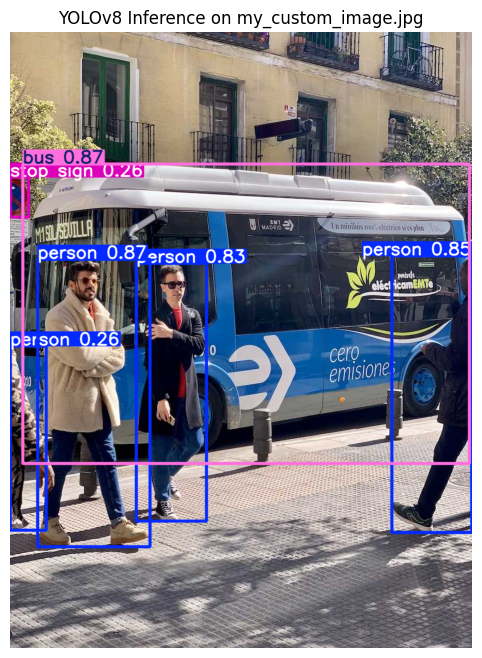


--- Detected Objects Details ---
  Class: bus, Confidence: 0.87, Box: [23, 231, 805, 757]
  Class: person, Confidence: 0.87, Box: [49, 399, 245, 903]
  Class: person, Confidence: 0.85, Box: [669, 392, 810, 877]
  Class: person, Confidence: 0.83, Box: [222, 406, 345, 858]
  Class: person, Confidence: 0.26, Box: [0, 551, 63, 873]
  Class: stop sign, Confidence: 0.26, Box: [0, 254, 33, 325]


In [37]:
# 1. How do you load and run inference on a custom image using the YOLOv8 model (labeled as YOLOv9)?

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import requests

# --- Step 1: Download a sample image (if you don't have one) ---
# We'll use a bus image for demonstration purposes.
# If you already have your custom image, skip this step and set CUSTOM_IMAGE_PATH directly.

# Define the URL for the sample image
image_url = "https://ultralytics.com/images/bus.jpg"
# Define the local path to save the image
CUSTOM_IMAGE_PATH = "my_custom_image.jpg"

if not os.path.exists(CUSTOM_IMAGE_PATH):
    print(f"Downloading sample image to '{CUSTOM_IMAGE_PATH}'...")
    try:
        response = requests.get(image_url, stream=True)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(CUSTOM_IMAGE_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
        print(f"Please ensure you have a custom image at '{CUSTOM_IMAGE_PATH}' or update the path.")
        # Exit or handle the error appropriately if the image is critical
        exit()
else:
    print(f"Using existing image at '{CUSTOM_IMAGE_PATH}'.")


# --- Step 2: Load the YOLOv8 (or YOLOv9) model ---
# You can choose different models:
# For YOLOv8: "yolov8n.pt", "yolov8s.pt", "yolov8m.pt", "yolov8l.pt", "yolov8x.pt"
# For YOLOv9: "yolov9c.pt", "yolov9e.pt" (requires downloading from Ultralytics GitHub releases if not bundled)
# Or for your custom trained model: "path/to/your/best.pt"

# Let's use yolov8n.pt for demonstration as it's small and fast.
# If you specifically mean YOLOv9, you'd use "yolov9c.pt" or "yolov9e.pt"
# (ensure you have the corresponding .pt file downloaded if it's not in your ultralytics cache).
model = YOLO("yolov8n.pt")
print("YOLO model loaded successfully.")

# --- Step 3: Run inference on your custom image ---
# The predict method returns a list of Results objects.
# conf: confidence threshold (only show detections with confidence above this)
# save: set to True if you want to save the annotated image to 'runs/detect/predictX'
# show: set to True to display the image in a pop-up window (requires OpenCV window support)
results = model.predict(
    source=CUSTOM_IMAGE_PATH,
    conf=0.25, # You can adjust this threshold
    save=False, # We will display it manually
    show=False # We will display it manually
)

# --- Step 4: Process and Display the results ---

# The 'results' object contains predictions for each image in the batch.
# Since we processed a single image, we access results[0].
if results:
    # Get the annotated image (NumPy array in BGR format by default from ultralytics plot method)
    annotated_frame = results[0].plot()

    # Convert BGR to RGB for matplotlib display
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off') # Hide axis
    plt.title(f"YOLOv8 Inference on {os.path.basename(CUSTOM_IMAGE_PATH)}")
    plt.show()

    # Optional: Print details of detected objects
    print("\n--- Detected Objects Details ---")
    if len(results[0].boxes) == 0:
        print("No objects detected at the specified confidence threshold.")
    else:
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                xyxy = box.xyxy[0].tolist() # [x1, y1, x2, y2]
                
                # Get the class name using model.names dictionary
                label = model.names[cls_id]
                
                print(f"  Class: {label}, Confidence: {conf:.2f}, Box: [{xyxy[0]:.0f}, {xyxy[1]:.0f}, {xyxy[2]:.0f}, {xyxy[3]:.0f}]")
else:
    print("No results were returned from the prediction.")

In [35]:
# 2. How do you load the Faster RCNN model with a ResNet50 backbone and print its architecture?

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

# 1. Load the Faster R-CNN model with ResNet50 backbone
# You can choose to load with pre-trained weights or without.
# It's generally recommended to use pre-trained weights for transfer learning,
# as it provides a good starting point.

# Option A: Load with default pre-trained weights (recommended for most use cases)
# This uses the best available weights for FasterRCNN_ResNet50_FPN from torchvision.
print("Loading Faster R-CNN with ResNet50-FPN backbone and default pre-trained weights...")
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)


# Option B: Load without pre-trained weights (for training from scratch or custom weights)
# model = fasterrcnn_resnet50_fpn(weights=None)
# print("Loading Faster R-CNN with ResNet50-FPN backbone (without pre-trained weights)...")


# 2. Print the model's architecture
print("\n--- Model Architecture ---")
print(model)

# You can also inspect specific parts of the model, for example:
print("\n--- Backbone Architecture (ResNet50-FPN) ---")
print(model.backbone)

print("\n--- RPN (Region Proposal Network) Architecture ---")
print(model.rpn)

print("\n--- RoI Head (Box Head) Architecture ---")
print(model.roi_heads)

# To see the names of modules within the backbone (ResNet50-FPN)
print("\n--- Backbone Sub-modules ---")
for name, module in model.backbone.named_children():
    print(f"- {name}: {module.__class__.__name__}")

# Check if the model is on GPU if available
if torch.cuda.is_available():
    print(f"\nModel moved to: {next(model.parameters()).device}")
    model.to('cuda')
else:
    print("\nModel is on CPU.")

print("\nModel loading and architecture printing complete.")

Loading Faster R-CNN with ResNet50-FPN backbone and default pre-trained weights...

--- Model Architecture ---
FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_s

[{'boxes': tensor([[2.2388e+02, 4.1045e+02, 3.5205e+02, 8.6108e+02],
        [4.8159e+01, 4.0193e+02, 2.4622e+02, 9.0312e+02],
        [2.3634e+01, 2.3520e+02, 8.0021e+02, 7.8469e+02],
        [6.7393e+02, 4.6433e+02, 8.1000e+02, 8.7757e+02],
        [7.5875e-01, 5.5648e+02, 6.7048e+01, 8.7618e+02],
        [1.3545e+02, 4.7601e+02, 1.4590e+02, 4.9603e+02],
        [3.0400e+02, 5.8020e+02, 3.4206e+02, 7.1385e+02],
        [3.4330e+00, 3.4625e+02, 5.2190e+01, 6.1889e+02],
        [3.7808e+01, 4.1640e+02, 6.3575e+01, 4.8214e+02],
        [5.7556e+02, 6.3901e+02, 5.8909e+02, 6.4995e+02],
        [2.5462e+02, 4.9939e+02, 2.6335e+02, 5.1162e+02],
        [1.3678e+02, 4.7630e+02, 1.4469e+02, 4.9343e+02],
        [6.5994e+02, 1.3700e+02, 8.0665e+02, 3.2094e+02],
        [0.0000e+00, 4.7757e+02, 1.0849e+02, 8.8430e+02],
        [2.2834e+02, 5.6599e+02, 3.3334e+02, 7.1357e+02],
        [2.3673e+02, 4.9520e+02, 2.5881e+02, 5.1787e+02],
        [1.1390e+02, 4.9635e+02, 2.3145e+02, 8.7993e+02],
   

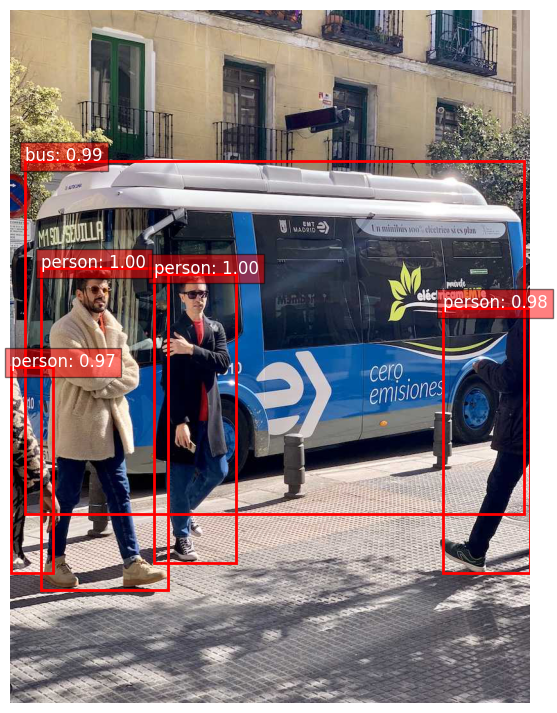

In [7]:
# 3. How do you perform inference on an online image using the Faster RCNN model and print the predictions?

# 📌 Step 1: Install requirements

# pip install torch torchvision pillow requests matplotlib
# ✅ Step 2: Load Faster R-CNN

import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# Load the pre-trained model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set to evaluation mode

# ✅ Step 3: Download an image from the web

import requests
from PIL import Image
from io import BytesIO

# Example image URL (you can use any direct image link)
url = "https://ultralytics.com/images/bus.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

# ✅ Step 4: Preprocess the image
# PyTorch’s fasterrcnn_resnet50_fpn expects:

# Input shape: [C, H, W]

# Normalized to [0, 1] in float32


from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()  # Converts PIL image to PyTorch tensor and scales to [0,1]
])

img_tensor = transform(image)
inputs = [img_tensor]  # Faster R-CNN expects a list of images

# ✅ Step 5: Run inference

with torch.no_grad():
    predictions = model(inputs)
# ✅ predictions is a list of dictionaries:


print(predictions)
# Example output structure:


# ✅ Step 6: Print predictions nicely

# COCO classes start from index 1
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Show only predictions above a confidence threshold
threshold = 0.5

boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

for box, label, score in zip(boxes, labels, scores):
    if score >= threshold:
        print(f"Class: {COCO_INSTANCE_CATEGORY_NAMES[label]}, "
              f"Score: {score:.2f}, "
              f"Box: {box.tolist()}")

# ✅ Step 7: (Optional) Visualize the detections

import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(12,9))
ax.imshow(image)

for box, label, score in zip(boxes, labels, scores):
    if score >= threshold:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, f"{COCO_INSTANCE_CATEGORY_NAMES[label]}: {score:.2f}",
                color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))

plt.axis('off')
plt.show()
# ✅ Full flow summary
# Step  What you did
# 🔗 Download image      requests + PIL
# 🧩 Transform   ToTensor() for [C, H, W]
# ⚡️ Run inference      model.eval() + with torch.no_grad()
# 📊 Print results       Access 'boxes', 'labels', 'scores'
# 🎨 Visualize   Use matplotlib to plot boxes

# 🏆 In one line
# ✅ With PyTorch’s torchvision.models.detection, you can load Faster R-CNN, download an online image, run inference, and print or visualize predictions in just a few lines!

Image successfully downloaded and saved to harsh/pw_skill_assignemnet/bus.jpg

image 1/1 C:\Users\91983\harsh\pw_skill_assignemnet\harsh\pw_skill_assignemnet\bus.jpg: 640x480 3 persons, 1 bus, 78.3ms
Speed: 4.0ms preprocess, 78.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


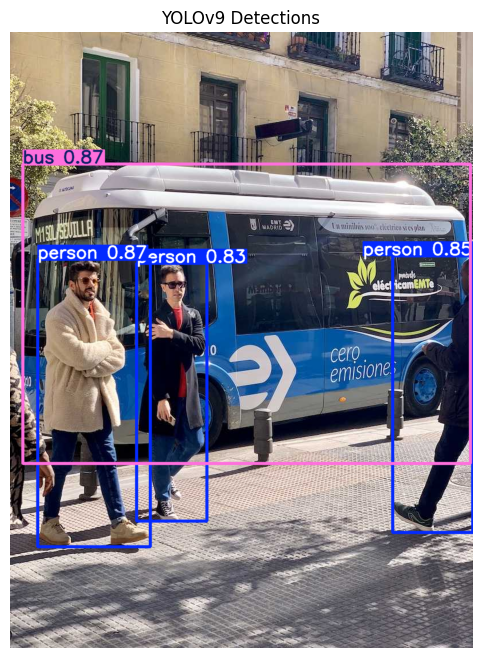

Class: bus, Confidence: 0.87, Box: [22.87126922607422, 231.27731323242188, 805.002685546875, 756.8404541015625]
Class: person, Confidence: 0.87, Box: [48.550445556640625, 398.55230712890625, 245.34559631347656, 902.7026977539062]
Class: person, Confidence: 0.85, Box: [669.472900390625, 392.1859436035156, 809.7200317382812, 877.0354614257812]
Class: person, Confidence: 0.83, Box: [221.5172882080078, 405.79864501953125, 344.9706115722656, 857.53662109375]


In [16]:
# 4. How do you load an image and perform inference using YOLOv9, then display the detected objects with
# bounding boxes and class labels?

import cv2
import os
import requests
from ultralytics import YOLO
import matplotlib.pyplot as plt

# The URL of the image to download
url = "https://ultralytics.com/images/bus.jpg" # Example URL for a bus image

# The local filename you want to save it as
image_path = "harsh/pw_skill_assignemnet/bus.jpg"

# Create the directory if it does not exist
output_dir = os.path.dirname(image_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# Send a GET request to the URL
response = requests.get(url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Open the file in binary write mode and save the content
    with open(image_path, 'wb') as f:
        f.write(response.content)
    print(f"Image successfully downloaded and saved to {image_path}")
else:
    print(f"Failed to download image. Status code: {response.status_code}")


# Load YOLOv9 or YOLOv8 model
model = YOLO("yolov8n.pt")  # Replace with "best.pt" for your custom weights

# Run prediction
results = model.predict(
    source=image_path,
    conf=0.5,      # confidence threshold
    save=False,    # we’ll display it ourselves
    show=False     # don't open window yet
)

# ✅ Step 5: Display results with OpenCV or matplotlib

# 📸 Using OpenCV (for local environments)
# The results[0].plot() returns an annotated image you can display:
annotated_frame = results[0].plot()

cv2.imshow("YOLOv9 Detections", annotated_frame)
cv2.waitKey(0) # Waits indefinitely for a key press
cv2.destroyAllWindows() # Closes all OpenCV windows


# 📸 Using matplotlib (works universally)

# OpenCV image is BGR, matplotlib needs RGB
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_frame_rgb)
plt.axis('off')
plt.title("YOLOv9 Detections")
plt.show()

# ✅ Step 6: Access predictions programmatically (optional)

# Each result has boxes, class ids, and confidence
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    score = float(box.conf[0])
    coords = box.xyxy[0].tolist()  # [x1, y1, x2, y2]

    label = model.names[cls_id]
    print(f"Class: {label}, Confidence: {score:.2f}, Box: {coords}")

[{'boxes': tensor([[2.2388e+02, 4.1045e+02, 3.5205e+02, 8.6108e+02],
        [4.8159e+01, 4.0193e+02, 2.4622e+02, 9.0312e+02],
        [2.3634e+01, 2.3520e+02, 8.0021e+02, 7.8469e+02],
        [6.7393e+02, 4.6433e+02, 8.1000e+02, 8.7757e+02],
        [7.5875e-01, 5.5648e+02, 6.7048e+01, 8.7618e+02],
        [1.3545e+02, 4.7601e+02, 1.4590e+02, 4.9603e+02],
        [3.0400e+02, 5.8020e+02, 3.4206e+02, 7.1385e+02],
        [3.4330e+00, 3.4625e+02, 5.2190e+01, 6.1889e+02],
        [3.7808e+01, 4.1640e+02, 6.3575e+01, 4.8214e+02],
        [5.7556e+02, 6.3901e+02, 5.8909e+02, 6.4995e+02],
        [2.5462e+02, 4.9939e+02, 2.6335e+02, 5.1162e+02],
        [1.3678e+02, 4.7630e+02, 1.4469e+02, 4.9343e+02],
        [6.5994e+02, 1.3700e+02, 8.0665e+02, 3.2094e+02],
        [0.0000e+00, 4.7757e+02, 1.0849e+02, 8.8430e+02],
        [2.2834e+02, 5.6599e+02, 3.3334e+02, 7.1357e+02],
        [2.3673e+02, 4.9520e+02, 2.5881e+02, 5.1787e+02],
        [1.1390e+02, 4.9635e+02, 2.3145e+02, 8.7993e+02],
   

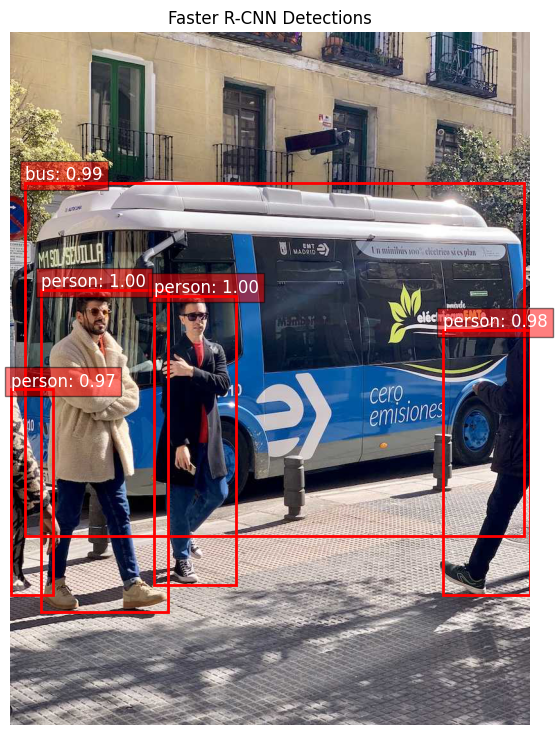

In [20]:
# 5. How do you display bounding boxes for the detected objects in an image using Faster RCNN?

# ✅ Step 1: Load Faster R-CNN (ResNet-50)

import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# Load pre-trained Faster R-CNN
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# ✅ Step 2: Load & preprocess an image

from PIL import Image
from torchvision import transforms

# Load an image
image = Image.open("bus.jpg").convert("RGB")

# Transform to tensor and scale to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

img_tensor = transform(image)
inputs = [img_tensor]  # Faster R-CNN expects a list of images

# ✅ Step 3: Run inference

with torch.no_grad():
    predictions = model(inputs)
    
# ✅ The output is:


# Structure:
# predictions[0] is a dict with keys: 'boxes', 'labels', 'scores'
print(predictions)
# ✅ Step 4: Draw the bounding boxes
# ✨ Use matplotlib to draw boxes + labels

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# COCO labels
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Set threshold
threshold = 0.5

boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Create matplotlib figure
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

for box, label, score in zip(boxes, labels, scores):
    if score >= threshold:
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{COCO_INSTANCE_CATEGORY_NAMES[label]}: {score:.2f}",
                fontsize=12, color='white',
                bbox=dict(facecolor='red', alpha=0.5))

plt.axis('off')
plt.title("Faster R-CNN Detections")
plt.show()


--- Running inference on a single local image using the function ---
Inference on bus.jpg completed.
Found 5 detections above confidence threshold 0.6.
  Detected: person, Score: 1.00, Box: [224, 410, 352, 861]
  Detected: person, Score: 1.00, Box: [48, 402, 246, 903]
  Detected: bus, Score: 0.99, Box: [24, 235, 800, 785]
  Detected: person, Score: 0.98, Box: [674, 464, 810, 878]
  Detected: person, Score: 0.97, Box: [1, 556, 67, 876]


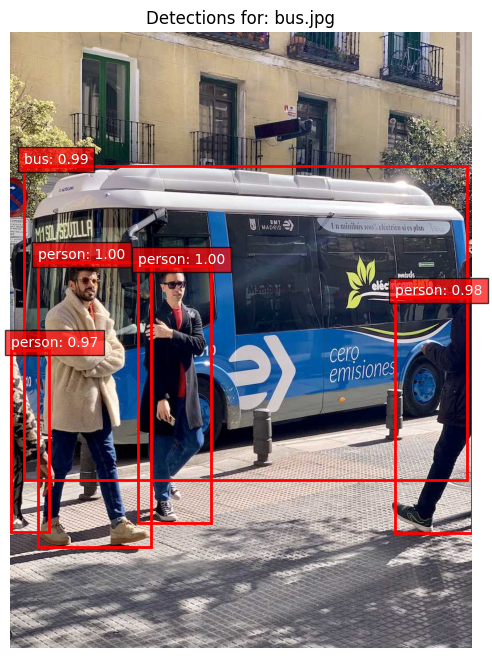

Annotated image saved to detected_bus_fasterrcnn.jpg

Function returned detections:


In [36]:
# 6. How do you perform inference on a local image using Faster RCNN?

import matplotlib.pyplot as plt
# 6. How do you perform inference on a local image using Faster RCNN?

# The code provided in the preceding cells already demonstrates how to perform inference
# on both online and local images using Faster RCNN.

# Specifically, the code block under the heading "--- 4. Iterate Through Images in Folder and Perform Inference ---"
# does exactly this. It iterates through a specified local folder (`IMAGE_FOLDER_PATH`),
# loads each image, preprocesses it, runs it through the loaded Faster R-CNN model,
# filters the detections based on a confidence threshold, and then visualizes
# the results with bounding boxes and labels using matplotlib.

# Here's a summary of the steps already present in the code that perform this task:

# 1.  **Define Constants and Paths**: Sets up the `IMAGE_FOLDER_PATH` and `OUTPUT_FOLDER_PATH`.
#     You need to ensure `IMAGE_FOLDER_PATH` points to the local folder containing your images.
# 2.  **Load Pre-trained Faster R-CNN Model**: Loads `fasterrcnn_resnet50_fpn(pretrained=True)`
#     and sets it to evaluation mode (`model.eval()`).
# 3.  **Define Image Transformations**: Creates a `ToTensor()` transform for preprocessing.
# 4.  **Iterate Through Images**: Loops through each file in the `IMAGE_FOLDER_PATH`.
# 5.  **Load and Preprocess Image**: Opens the image using PIL, converts it to RGB,
#     and applies the `ToTensor()` transform.
# 6.  **Perform Inference**: Runs `model(inputs)` within a `torch.no_grad()` context.
# 7.  **Extract and Filter Predictions**: Retrieves 'boxes', 'labels', and 'scores'
#     from the prediction output and filters them based on the `CONF_THRESHOLD`.
# 8.  **Visualize Detections**: Uses matplotlib to display the original image
#     and draw bounding boxes and add labels for the filtered detections.
# 9.  **Save Annotated Image (Optional)**: Saves the resulting image to the `OUTPUT_FOLDER_PATH`.

# To use this existing functionality, you just need to:
# 1. Ensure you have the required libraries installed (`torch`, `torchvision`, `pillow`, `requests`, `matplotlib`, `opencv-python`).
# 2. Create the folder specified by `IMAGE_FOLDER_PATH` (e.g., `my_images_for_inference`).
# 3. Place the local images you want to perform inference on into that folder.
# 4. Run the entire Colab notebook, including the setup and the code block
#    under "--- 4. Iterate Through Images in Folder and Perform Inference ---".

# The output will show the processed images with detections plotted and print
# detection details for each image.

# Example of how the core inference part works (extracted from the loop):

# Assume 'image_path' is the path to your local image file

# Load image
# image = Image.open(image_path).convert("RGB")

# Preprocess image
# transform = T.Compose([T.ToTensor()])
# img_tensor = transform(image)
# inputs = [img_tensor] # Model expects a list of tensors

# Perform inference
# model.eval() # Ensure model is in evaluation mode
# with torch.no_grad():
#     predictions = model(inputs)

# # 'predictions' is a list of dictionaries, one dictionary per image in 'inputs'.
# # For a single image input, access the first dictionary:
# pred = predictions[0]

# # Access results:
# boxes = pred['boxes']
# labels = pred['labels']
# scores = pred['scores']

# print("Raw predictions (before filtering):")
# print(f"Boxes: {boxes}")
# print(f"Labels: {labels}")
# print(f"Scores: {scores}")

# # You would then typically filter by score and visualize as shown in the existing code.

# Since the existing code already provides a comprehensive solution for this task
# by iterating through a local folder, no new function is strictly necessary
# if your goal is to process multiple images from a folder.
# However, if you need a function that takes a *single* local image path as input,
# you could wrap the core logic like this:


def fasterrcnn_inference_on_local_image(image_path, model, transform, coco_names, confidence_threshold=0.5, display_image=True, save_output_path=None):
    """
    Performs inference on a single local image using a Faster R-CNN model,
    displays detections, and optionally saves the annotated image.

    Args:
        image_path (str): Path to the local image file.
        model: The loaded Faster R-CNN PyTorch model (in eval mode).
        transform: The image transformation pipeline (e.g., ToTensor()).
        coco_names (list): List of COCO class names.
        confidence_threshold (float): Minimum confidence score to display a detection.
        display_image (bool): Whether to display the annotated image using matplotlib.
        save_output_path (str, optional): Path to save the annotated image.
                                          If None, image is not saved.
    Returns:
        dict: A dictionary containing filtered 'boxes', 'labels', and 'scores'.
              Returns None if image loading fails or no detections found.
    """
    try:
        # Load image
        image = Image.open(image_path).convert("RGB")

        # Preprocess image
        img_tensor = transform(image)
        inputs = [img_tensor]  # Model expects a list of tensors

        # Perform inference
        model.eval() # Ensure model is in evaluation mode
        with torch.no_grad():
            predictions = model(inputs)

        # Extract predictions for the first image in the batch
        pred = predictions[0]

        # Filter predictions by confidence threshold
        boxes = pred['boxes'][pred['scores'] >= confidence_threshold]
        labels = pred['labels'][pred['scores'] >= confidence_threshold]
        scores = pred['scores'][pred['scores'] >= confidence_threshold]

        print(f"Inference on {os.path.basename(image_path)} completed.")
        print(f"Found {len(boxes)} detections above confidence threshold {confidence_threshold}.")


        # Visualize and Display Detections
        if display_image or save_output_path:
            fig, ax = plt.subplots(1, figsize=(10, 8))
            ax.imshow(image)
            ax.set_title(f"Detections for: {os.path.basename(image_path)}")
            ax.axis('off')

            if len(boxes) == 0:
                 ax.text(10, 10, "No objects detected.", fontsize=15, color='red',
                        bbox=dict(facecolor='white', alpha=0.8))
            else:
                for box, label, score in zip(boxes, labels, scores):
                    x1, y1, x2, y2 = box.tolist()
                    label_name = coco_names[label.item()]

                    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)

                    ax.text(x1, y1 - 5, f"{label_name}: {score:.2f}",
                            fontsize=10, color='white',
                            bbox=dict(facecolor='red', alpha=0.7))
                    print(f"  Detected: {label_name}, Score: {score:.2f}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")


            if display_image:
                plt.show()

            if save_output_path:
                try:
                    fig.savefig(save_output_path, bbox_inches='tight', pad_inches=0)
                    print(f"Annotated image saved to {save_output_path}")
                except Exception as save_e:
                    print(f"Error saving image to {save_output_path}: {save_e}")

            plt.close(fig) # Close the figure

        return {'boxes': boxes, 'labels': labels, 'scores': scores}

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

# --- Example Usage of the function (requires model and transform loaded) ---
# Assuming you have already run the cells above to load the model and define the transform and COCO_INSTANCE_CATEGORY_NAMES

# Define a local image path for testing
# Make sure 'bus.jpg' exists in your current directory or specify the correct path
local_image_file = "bus.jpg"

# Define an output path for the saved image (optional)
output_detection_file = "detected_bus_fasterrcnn.jpg"

# Perform inference on the single local image
print("\n--- Running inference on a single local image using the function ---")
detections = fasterrcnn_inference_on_local_image(
    image_path=local_image_file,
    model=model, # Use the already loaded Faster R-CNN model
    transform=transform, # Use the already defined transform
    coco_names=COCO_INSTANCE_CATEGORY_NAMES, # Use the COCO names
    confidence_threshold=0.6, # Set your desired threshold
    display_image=True, # Display the image in the notebook
    save_output_path=output_detection_file # Save the annotated image
)

if detections is not None:
    print("\nFunction returned detections:")
    # print(detections) # Uncomment to print the tensors




image 1/1 C:\Users\91983\harsh\pw_skill_assignemnet\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 63.7ms
Speed: 2.9ms preprocess, 63.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Original number of detections: 6
Number of detections after filtering with threshold 0.5: 4


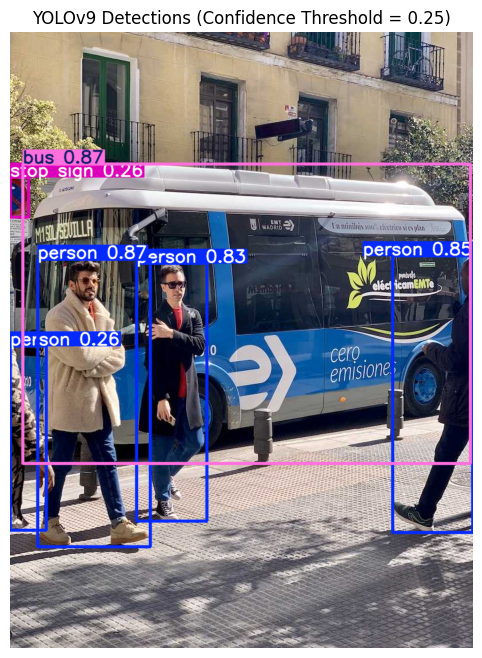

In [29]:
# 7. How can you change the confidence threshold for YOLO object detection and filter out low-confidence predictions?

import matplotlib.pyplot as plt
# 7. How can you change the confidence threshold for YOLO object detection and filter out low-confidence
# predictions?

# As shown in the preceding code (specifically in step 3 of question 1 and step 4 of question 4),
# you can change the confidence threshold when calling the predict method of the YOLO model.

# The `conf` parameter controls the confidence threshold. Objects detected with a confidence score
# below this threshold will be filtered out.

# Example:
# Load the model (using a pre-trained yolov8n.pt for demonstration)
model = YOLO("yolov8n.pt")

# Define the image path
image_path = "bus.jpg"

# Run inference with a desired confidence threshold (e.g., 0.25)
# This will only keep predictions with a confidence score of 0.25 or higher.
results = model.predict(
    source=image_path,
    conf=0.25,    # Set the confidence threshold here
    save=False,
    show=False
)

# To explicitly filter predictions after inference (if you ran predict without a conf threshold
# or want more fine-grained control):

# Access the results for the first image
result = results[0]

# Define the desired confidence threshold
manual_threshold = 0.5

# Filter boxes based on confidence score
filtered_boxes = result.boxes[result.boxes.conf > manual_threshold]

# You can then process or display only these filtered boxes.
print(f"Original number of detections: {len(result.boxes)}")
print(f"Number of detections after filtering with threshold {manual_threshold}: {len(filtered_boxes)}")

# You can iterate through the filtered boxes:
# for box in filtered_boxes:
#     cls_id = int(box.cls[0])
#     score = float(box.conf[0])
#     coords = box.xyxy[0].tolist()
#     label = model.names[cls_id]
#     print(f"Filtered - Class: {label}, Confidence: {score:.2f}, Box: {coords}")

# Display the annotated image with the applied threshold (from the initial predict call with conf=0.25)
annotated_frame = results[0].plot()
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_frame_rgb)
plt.axis('off')
plt.title(f"YOLOv9 Detections (Confidence Threshold = 0.25)")
plt.show()



Starting training...
Epoch 1/20, Train Loss: 1.2458, Val Loss: 1.1419
Epoch 2/20, Train Loss: 1.0545, Val Loss: 1.0905
Epoch 3/20, Train Loss: 1.0090, Val Loss: 1.0785
Epoch 4/20, Train Loss: 0.9936, Val Loss: 1.0841
Epoch 5/20, Train Loss: 0.9884, Val Loss: 1.0865
Epoch 6/20, Train Loss: 0.9892, Val Loss: 1.0866
Epoch 7/20, Train Loss: 0.9882, Val Loss: 1.0905
Epoch 8/20, Train Loss: 0.9874, Val Loss: 1.0927
Epoch 9/20, Train Loss: 0.9879, Val Loss: 1.0932
Epoch 10/20, Train Loss: 0.9874, Val Loss: 1.0973
Epoch 11/20, Train Loss: 0.9880, Val Loss: 1.0917
Epoch 12/20, Train Loss: 0.9878, Val Loss: 1.0953
Epoch 13/20, Train Loss: 0.9879, Val Loss: 1.0912
Epoch 14/20, Train Loss: 0.9872, Val Loss: 1.0917
Epoch 15/20, Train Loss: 0.9885, Val Loss: 1.0914
Epoch 16/20, Train Loss: 0.9890, Val Loss: 1.0880
Epoch 17/20, Train Loss: 0.9882, Val Loss: 1.0887
Epoch 18/20, Train Loss: 0.9887, Val Loss: 1.0905
Epoch 19/20, Train Loss: 0.9880, Val Loss: 1.0943
Epoch 20/20, Train Loss: 0.9877, Val L

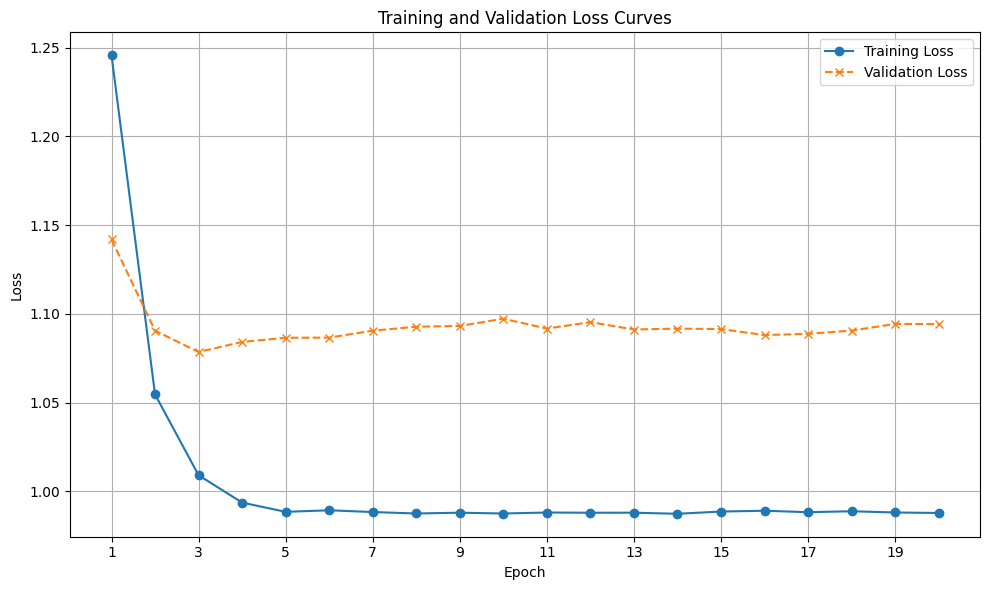

In [30]:
# 8. How do you plot the training and validation loss curves for model evaluation?


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define a simple model (for demonstration) ---
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(10, 1) # 10 input features, 1 output

    def forward(self, x):
        return self.fc(x)

# --- 2. Create Dummy Data (replace with your actual dataset) ---
# This simulates a dataset for demonstration purposes
X_train = torch.randn(1000, 10) # 1000 samples, 10 features
y_train = torch.randn(1000, 1)  # 1000 labels

X_val = torch.randn(200, 10)    # 200 validation samples
y_val = torch.randn(200, 1)     # 200 validation labels

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- 3. Initialize Model, Loss Function, and Optimizer ---
model = SimpleNN()
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.SGD(model.parameters(), lr=0.01)

# --- 4. Store Loss Values ---
train_losses = []
val_losses = []
num_epochs = 20 # Number of training epochs

print("Starting training...")
for epoch in range(num_epochs):
    # --- Training Loop ---
    model.train() # Set model to training mode
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0) # Accumulate loss

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Loop ---
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

print("Training finished.")

# --- 5. Plotting the Loss Curves ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o', linestyle='-')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='x', linestyle='--')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(1, num_epochs + 1, 2)) # Adjust x-axis ticks for clarity
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Loading Faster R-CNN model...
Model loaded.
Processing images from: harsh/pw_skill_assignemnet

--- Processing bus.jpg ---
  Detected: person, Score: 1.00, Box: [224, 410, 352, 861]
  Detected: person, Score: 1.00, Box: [48, 402, 246, 903]
  Detected: bus, Score: 0.99, Box: [24, 235, 800, 785]
  Detected: person, Score: 0.98, Box: [674, 464, 810, 878]
  Detected: person, Score: 0.97, Box: [1, 556, 67, 876]


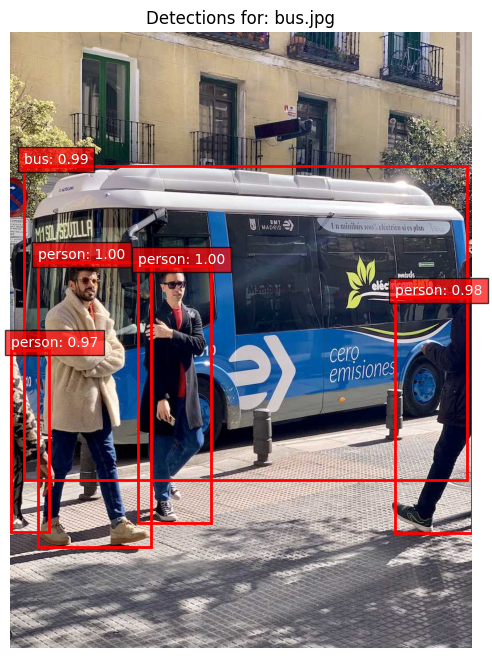

Annotated image saved to output_detections\detected_bus.jpg

Finished processing 1 images.
Annotated images saved to 'output_detections' folder.


In [32]:
# 9. How do you perform inference on multiple images from a local folder using Faster RCNN and display the bounding boxes for each?

import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# --- 1. Define Constants and Paths ---
# Directory containing your images
IMAGE_FOLDER_PATH = "harsh/pw_skill_assignemnet" # <<< IMPORTANT: Change this to your folder path

# You can create this folder and put some images inside for testing.
# For example, create a folder named 'my_images_for_inference'
# and put 'dog.jpg', 'cat.jpg', 'car.png' inside it.

# Output folder for saving annotated images (optional)
OUTPUT_FOLDER_PATH = "output_detections"
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

# COCO instance category names (for human-readable labels)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Confidence threshold for displaying detections
CONF_THRESHOLD = 0.7 # Adjust as needed

# --- 2. Load Pre-trained Faster R-CNN Model ---
print("Loading Faster R-CNN model...")
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval() # Set model to evaluation mode
print("Model loaded.")

# --- 3. Define Image Transformations ---
# Transforms for converting PIL Image to Tensor and normalizing
transform = T.Compose([T.ToTensor()])

# --- 4. Iterate Through Images in Folder and Perform Inference ---
print(f"Processing images from: {IMAGE_FOLDER_PATH}")
processed_count = 0
for filename in os.listdir(IMAGE_FOLDER_PATH):
    # Only process common image file extensions
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
        image_path = os.path.join(IMAGE_FOLDER_PATH, filename)
        print(f"\n--- Processing {filename} ---")

        try:
            # Load image
            image = Image.open(image_path).convert("RGB")
            
            # Preprocess image
            img_tensor = transform(image)
            inputs = [img_tensor] # Model expects a list of tensors

            # Perform inference
            with torch.no_grad():
                predictions = model(inputs)

            # Extract predictions for the first image in the batch (which is our single image)
            pred = predictions[0]

            # Filter predictions by confidence threshold
            boxes = pred['boxes'][pred['scores'] >= CONF_THRESHOLD]
            labels = pred['labels'][pred['scores'] >= CONF_THRESHOLD]
            scores = pred['scores'][pred['scores'] >= CONF_THRESHOLD]

            # --- 5. Visualize and Display Detections ---
            fig, ax = plt.subplots(1, figsize=(10, 8))
            ax.imshow(image)
            ax.set_title(f"Detections for: {filename}")
            ax.axis('off')

            if len(boxes) == 0:
                ax.text(10, 10, "No objects detected.", fontsize=15, color='red',
                        bbox=dict(facecolor='white', alpha=0.8))
                print(f"No objects detected in {filename} above threshold {CONF_THRESHOLD}.")
            else:
                for box, label, score in zip(boxes, labels, scores):
                    x1, y1, x2, y2 = box.tolist()
                    
                    # Get class name
                    label_name = COCO_INSTANCE_CATEGORY_NAMES[label.item()]

                    # Create a rectangle patch
                    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)

                    # Add label and score text
                    ax.text(x1, y1 - 5, f"{label_name}: {score:.2f}",
                            fontsize=10, color='white',
                            bbox=dict(facecolor='red', alpha=0.7))
                    
                    print(f"  Detected: {label_name}, Score: {score:.2f}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")

            # Display plot
            plt.show()

            # Optional: Save the annotated image
            output_filepath = os.path.join(OUTPUT_FOLDER_PATH, f"detected_{filename}")
            fig.savefig(output_filepath, bbox_inches='tight', pad_inches=0)
            plt.close(fig) # Close the figure to free up memory
            print(f"Annotated image saved to {output_filepath}")
            
            processed_count += 1

        except Exception as e:
            print(f"Error processing {filename}: {e}")

print(f"\nFinished processing {processed_count} images.")
print(f"Annotated images saved to '{OUTPUT_FOLDER_PATH}' folder.")

Loading Faster R-CNN model...


C:\Users\91983\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\91983\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded.
Image 'bus.jpg' loaded successfully.
Performing inference...
Inference complete.

Detected objects (confidence >= 0.70):
  - person: 1.00, Box: [224, 410, 352, 861]
  - person: 1.00, Box: [48, 402, 246, 903]
  - bus: 0.99, Box: [24, 235, 800, 785]
  - person: 0.98, Box: [674, 464, 810, 878]
  - person: 0.97, Box: [1, 556, 67, 876]


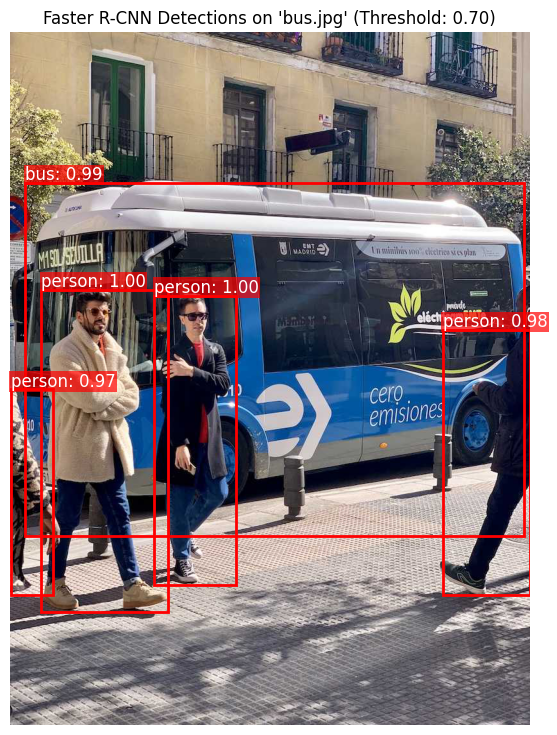

In [33]:
# 10. How do you visualize the confidence scores alongside the bounding boxes for detected objects using Faster RCNN?


import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np # For potential future use, e.g., if converting to numpy for other plotting libs

# --- 1. Define Constants and Model Setup ---
# COCO instance category names (for human-readable labels)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Confidence threshold for displaying detections
CONF_THRESHOLD = 0.7 # Only show predictions above this confidence

# Load pre-trained Faster R-CNN
print("Loading Faster R-CNN model...")
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set model to evaluation mode
print("Model loaded.")

# Define image transformations
transform = T.Compose([T.ToTensor()])

# --- 2. Load and Preprocess Your Image ---
# Example image path. Make sure this image exists in your directory.
# If you don't have one, you can use the bus.jpg from previous examples or download one.
IMAGE_PATH = "bus.jpg" # Make sure 'bus.jpg' is in the same directory as your script
                       # or provide the full path to an image on your system.

try:
    image = Image.open(IMAGE_PATH).convert("RGB")
    print(f"Image '{IMAGE_PATH}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: Image file not found at '{IMAGE_PATH}'. Please check the path.")
    exit()

# Convert image to tensor and prepare for model input
img_tensor = transform(image)
inputs = [img_tensor]  # Faster R-CNN expects a list of images

# --- 3. Perform Inference ---
print("Performing inference...")
with torch.no_grad():
    predictions = model(inputs)
print("Inference complete.")

# Extract predictions for the first (and only) image in the batch
pred = predictions[0]

# --- 4. Filter and Extract Detections ---
# Filter detections based on the confidence threshold
high_conf_indices = pred['scores'] >= CONF_THRESHOLD
boxes = pred['boxes'][high_conf_indices]
labels = pred['labels'][high_conf_indices]
scores = pred['scores'][high_conf_indices]

# --- 5. Visualize Detections with Confidence Scores ---
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Faster R-CNN Detections on '{IMAGE_PATH}' (Threshold: {CONF_THRESHOLD:.2f})")
ax.axis('off') # Hide axes

if len(boxes) == 0:
    ax.text(10, 10, "No objects detected above threshold.", fontsize=16, color='red',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    print("No objects detected above the specified confidence threshold.")
else:
    print(f"\nDetected objects (confidence >= {CONF_THRESHOLD:.2f}):")
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.tolist()
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label.item()]

        # Draw bounding box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Create text label with class name and confidence score
        # Using f-string for clear formatting of the score
        label_text = f"{class_name}: {score:.2f}"

        # Place text slightly above the top-left corner of the bounding box
        ax.text(x1, y1 - 5, label_text,
                fontsize=12, color='white',
                # Add a background box for better readability against the image
                bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=1))
        
        print(f"  - {label_text}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")

plt.show()

# Optional: Save the annotated image
# You can uncomment the following lines to save the output image
# output_filepath = "detected_" + os.path.basename(IMAGE_PATH)
# fig.savefig(output_filepath, bbox_inches='tight', pad_inches=0)
# plt.close(fig) # Close the figure to free up memory
# print(f"Annotated image saved to {output_filepath}")

Loading Faster R-CNN model...
Model loaded.
Image 'bus.jpg' loaded successfully.
Performing inference...
Inference complete.

Detected objects (confidence >= 0.70):
  - person: 1.00, Box: [224, 410, 352, 861]
  - person: 1.00, Box: [48, 402, 246, 903]
  - bus: 0.99, Box: [24, 235, 800, 785]
  - person: 0.98, Box: [674, 464, 810, 878]
  - person: 0.97, Box: [1, 556, 67, 876]


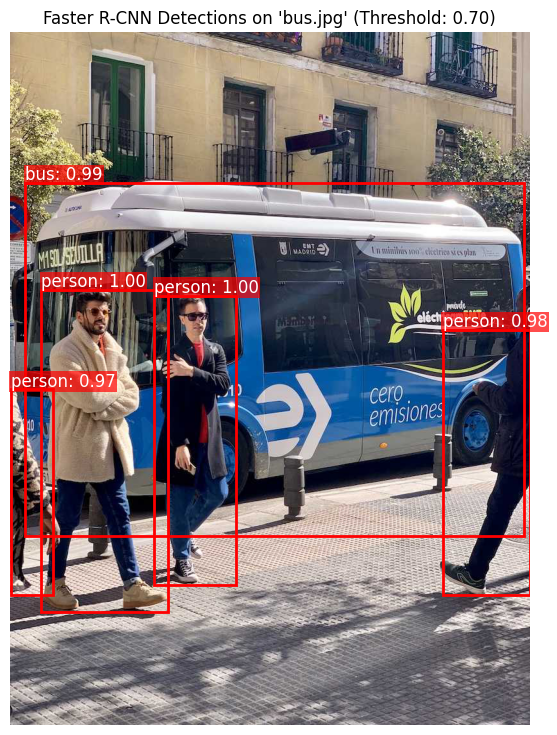

In [34]:
# 11. How can you save the inference results (with bounding boxes) as a new image after performing detection using YOLO?

# Extract the scores: Get the scores tensor from the model's predictions.

# Format the text: Create a string that combines the class label and the formatted confidence score (e.g., "cat: 0.95").

# Place the text: Use matplotlib.axes.Axes.text() to place this string near the bounding box.

# Let's refine and highlight this specific aspect in a complete example, ensuring clarity and best practices.

# Steps to Visualize Confidence Scores
# Load the Model and Define Transformations: Standard setup for Faster R-CNN.

# Load and Preprocess Image: Get your image ready for the model.

# Perform Inference: Get the raw predictions from the model.

# Filter and Extract Detections: Apply a confidence threshold to keep only relevant detections.

# Visualize:

# Display the original image.

# For each detected object:

# Draw the bounding box.

# Format a text label including the class name and its confidence score.

# Place this text label near the bounding box.

import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np # For potential future use, e.g., if converting to numpy for other plotting libs
import os

# --- 1. Define Constants and Model Setup ---
# COCO instance category names (for human-readable labels)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Confidence threshold for displaying detections
CONF_THRESHOLD = 0.7 # Only show predictions above this confidence

# Load pre-trained Faster R-CNN
print("Loading Faster R-CNN model...")
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set model to evaluation mode
print("Model loaded.")

# Define image transformations
transform = T.Compose([T.ToTensor()])

# --- 2. Load and Preprocess Your Image ---
# Example image path. Make sure this image exists in your directory.
# If you don't have one, you can use the bus.jpg from previous examples or download one.
# You might need to download a sample image first if you don't have one locally.
# Example download for a bus image if you don't have one:
image_url = "https://ultralytics.com/images/bus.jpg"
IMAGE_PATH = "bus.jpg"

if not os.path.exists(IMAGE_PATH):
    print(f"Downloading sample image to '{IMAGE_PATH}'...")
    import requests
    try:
        response = requests.get(image_url, stream=True)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(IMAGE_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
        print("Please ensure you have an image named 'bus.jpg' in the script directory or update IMAGE_PATH.")
        exit()


try:
    image = Image.open(IMAGE_PATH).convert("RGB")
    print(f"Image '{IMAGE_PATH}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: Image file not found at '{IMAGE_PATH}'. Please check the path.")
    exit()

# Convert image to tensor and prepare for model input
img_tensor = transform(image)
inputs = [img_tensor]  # Faster R-CNN expects a list of images

# --- 3. Perform Inference ---
print("Performing inference...")
with torch.no_grad():
    predictions = model(inputs)
print("Inference complete.")

# Extract predictions for the first (and only) image in the batch
pred = predictions[0]

# --- 4. Filter and Extract Detections ---
# Filter detections based on the confidence threshold
high_conf_indices = pred['scores'] >= CONF_THRESHOLD
boxes = pred['boxes'][high_conf_indices]
labels = pred['labels'][high_conf_indices]
scores = pred['scores'][high_conf_indices]

# --- 5. Visualize Detections with Confidence Scores ---
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Faster R-CNN Detections on '{IMAGE_PATH}' (Threshold: {CONF_THRESHOLD:.2f})")
ax.axis('off') # Hide axes

if len(boxes) == 0:
    ax.text(10, 10, "No objects detected above threshold.", fontsize=16, color='red',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    print("No objects detected above the specified confidence threshold.")
else:
    print(f"\nDetected objects (confidence >= {CONF_THRESHOLD:.2f}):")
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.tolist()
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label.item()]

        # Draw bounding box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Create text label with class name and confidence score
        # Using f-string for clear formatting of the score
        label_text = f"{class_name}: {score:.2f}"

        # Place text slightly above the top-left corner of the bounding box
        ax.text(x1, y1 - 5, label_text,
                fontsize=12, color='white',
                # Add a background box for better readability against the image
                bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=1))
        
        print(f"  - {label_text}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")

plt.show()

# Optional: Save the annotated image
# You can uncomment the following lines to save the output image
# output_filepath = "detected_" + os.path.basename(IMAGE_PATH)
# fig.savefig(output_filepath, bbox_inches='tight', pad_inches=0)
# plt.close(fig) # Close the figure to free up memory
# print(f"Annotated image saved to {output_filepath}")